# Layer Weight Candlestick Comparison

This notebook compares **two Hugging Face models** with two complementary views:
1. **Layer-level** candlesticks (all parameter blocks aggregated per layer index)
2. **Granular component-level** candlesticks at each layer index (for example `attention` vs `attention`, `mlp` vs `mlp`)

For each candlestick:
- Wick = **min / max excluding outliers**
- Body = **mean +/- 2 sigma**
- Horizontal line = **mean**
- Points = **outliers beyond 3 sigma**


In [1]:
import gc
import re
from collections import defaultdict
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import Rectangle
from transformers import AutoModel

try:
    import dotenv

    dotenv.load_dotenv()
except Exception:
    pass

/home/ant/Projects/qat-transfer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- Change these model names ----
MODEL_A = "openai/clip-vit-base-patch16"
MODEL_B = "timm/vit_base_patch16_224.augreg2_in21k_ft_in1k"
MODEL_A_LABEL = "openai_clip"
MODEL_B_LABEL = "timm_vit"

# ---- General knobs ----
TRUST_REMOTE_CODE = False
OUTLIER_SIGMA = 3.0
BODY_SIGMA = 2.0
MAX_OUTLIERS_PER_CANDLE = 1900
INCLUDE_UNINDEXED_PARAMETERS = False
DPI = 180
SAVE_LAYER_FIG_PATH = None  # e.g. "layer_weight_candlesticks.png"
SAVE_GRANULAR_FIG_PATH = None  # e.g. "layer5_component_candlesticks.png"
SAVE_GRANULAR_ACROSS_FIG_PATH = None
SAVE_GRANULAR_SINGLE_LAYER_FIG_PATH = None

# ---- Granular component matching mode ----
# "family" groups by high-level component classes (attention, mlp, norm, ...)
# "path" groups by normalized parameter path after the layer index
COMPONENT_MATCH_MODE = "family"
MAX_COMPONENT_LABEL_CHARS = 36

# ---- Granular plotting selection ----
LAYER_INDEX_TO_INSPECT = None  # e.g. 5 (uses first common layer when None)
PLOT_GRANULAR_FOR_ALL_COMMON_LAYERS = True  # True = one figure per layer index
# ---- Granular plotting controls ----
PLOT_GRANULAR_ACROSS_ALL_LAYERS = True
PLOT_GRANULAR_SINGLE_LAYER = False

In [3]:
_LAYER_CONTAINER_NAMES = {"layers", "layer", "blocks", "block", "resblocks", "stages", "h"}
_PARAM_TAIL_TOKENS = {"weight", "bias", "running_mean", "running_var", "num_batches_tracked"}


def _find_layer_index_and_tail_start(segments: List[str]) -> Tuple[Optional[int], Optional[int]]:
    for i, seg in enumerate(segments[:-1]):
        if seg in _LAYER_CONTAINER_NAMES and i + 1 < len(segments) and segments[i + 1].isdigit():
            return int(segments[i + 1]), i + 2

        if seg in {"encoder", "decoder", "transformer"} and i + 2 < len(segments):
            if segments[i + 1] in _LAYER_CONTAINER_NAMES and segments[i + 2].isdigit():
                return int(segments[i + 2]), i + 3

    for i, seg in enumerate(segments):
        if seg.isdigit():
            return int(seg), i + 1

    return None, None


def _strip_parameter_suffix(path_segments: List[str]) -> List[str]:
    stripped = [s.lower() for s in path_segments]
    while stripped and stripped[-1] in _PARAM_TAIL_TOKENS:
        stripped.pop()
    return stripped


def _normalize_component_name(path_segments: List[str], mode: str = "family") -> str:
    core = _strip_parameter_suffix(path_segments)
    if not core:
        return "misc"

    if mode == "path":
        return ".".join(core)

    if any(("attn" in seg) or ("attention" in seg) for seg in core):
        return "attention"
    if any(
        ("mlp" in seg)
        or ("ffn" in seg)
        or ("feedforward" in seg)
        or ("feed_forward" in seg)
        or ("intermediate" in seg)
        for seg in core
    ):
        return "mlp"
    if any(("norm" in seg) or seg.startswith("ln") for seg in core):
        return "norm"
    if any("embed" in seg for seg in core):
        return "embedding"
    if any("proj" in seg for seg in core):
        return "projection"

    return core[0]


def collect_grouped_parameter_blocks(
    model: torch.nn.Module,
    component_mode: str = "family",
) -> Tuple[Dict[int, List[np.ndarray]], Dict[int, Dict[str, List[np.ndarray]]], int]:
    grouped_by_layer: Dict[int, List[np.ndarray]] = defaultdict(list)
    grouped_by_component: Dict[int, Dict[str, List[np.ndarray]]] = defaultdict(
        lambda: defaultdict(list)
    )
    skipped_unindexed = 0

    for name, param in model.named_parameters():
        if not torch.is_floating_point(param):
            continue

        segments = name.split(".")
        layer_idx, tail_start = _find_layer_index_and_tail_start(segments)

        if layer_idx is None:
            if INCLUDE_UNINDEXED_PARAMETERS:
                layer_idx = -1
                tail_start = 0
            else:
                skipped_unindexed += 1
                continue

        tail_segments = segments[tail_start:] if tail_start is not None else []
        component_name = _normalize_component_name(tail_segments, mode=component_mode)

        values = param.detach().cpu().float().reshape(-1).numpy()
        grouped_by_layer[layer_idx].append(values)
        grouped_by_component[layer_idx][component_name].append(values)

    grouped_by_component_plain = {
        layer_idx: dict(comp_map) for layer_idx, comp_map in grouped_by_component.items()
    }
    return dict(grouped_by_layer), grouped_by_component_plain, skipped_unindexed


def compute_distribution_statistics(blocks: List[np.ndarray]) -> Dict[str, object]:
    values = np.concatenate(blocks)

    mean = float(values.mean())
    std = float(values.std())
    min_value = float(values.min())
    max_value = float(values.max())

    if std == 0.0:
        outlier_mask = np.zeros(values.shape, dtype=bool)
    else:
        lower = mean - OUTLIER_SIGMA * std
        upper = mean + OUTLIER_SIGMA * std
        outlier_mask = (values < lower) | (values > upper)

    outliers = values[outlier_mask]
    inliers = values[~outlier_mask]

    if inliers.size == 0:
        wick_min = min_value
        wick_max = max_value
    else:
        wick_min = float(inliers.min())
        wick_max = float(inliers.max())

    if MAX_OUTLIERS_PER_CANDLE is not None and outliers.size > MAX_OUTLIERS_PER_CANDLE:
        rng = np.random.default_rng(0)
        outliers = rng.choice(outliers, size=MAX_OUTLIERS_PER_CANDLE, replace=False)

    body_half = BODY_SIGMA * std
    return {
        "min": min_value,
        "max": max_value,
        "mean": mean,
        "std": std,
        "wick_min": wick_min,
        "wick_max": wick_max,
        "body_low": mean - body_half,
        "body_high": mean + body_half,
        "outliers": outliers,
        "n_values": int(values.size),
    }


def compute_layer_statistics(
    grouped_by_layer: Dict[int, List[np.ndarray]],
) -> Dict[int, Dict[str, object]]:
    stats: Dict[int, Dict[str, object]] = {}
    for layer_idx, blocks in sorted(grouped_by_layer.items()):
        layer_stats = compute_distribution_statistics(blocks)
        layer_stats["n_blocks"] = len(blocks)
        stats[layer_idx] = layer_stats
    return stats


def compute_component_statistics(
    grouped_by_component: Dict[int, Dict[str, List[np.ndarray]]],
) -> Dict[int, Dict[str, Dict[str, object]]]:
    stats: Dict[int, Dict[str, Dict[str, object]]] = {}
    for layer_idx, component_map in sorted(grouped_by_component.items()):
        stats[layer_idx] = {}
        for component_name, blocks in sorted(component_map.items()):
            component_stats = compute_distribution_statistics(blocks)
            component_stats["n_blocks"] = len(blocks)
            stats[layer_idx][component_name] = component_stats
    return stats


def load_model_statistics(
    model_name: str,
    component_mode: str = "family",
) -> Tuple[Dict[int, Dict[str, object]], Dict[int, Dict[str, Dict[str, object]]], int]:
    print(f"Loading model: {model_name}")
    model = AutoModel.from_pretrained(model_name, trust_remote_code=TRUST_REMOTE_CODE)
    model.eval()

    grouped_by_layer, grouped_by_component, skipped_unindexed = collect_grouped_parameter_blocks(
        model,
        component_mode=component_mode,
    )

    layer_stats = compute_layer_statistics(grouped_by_layer)
    component_stats = compute_component_statistics(grouped_by_component)

    del model
    gc.collect()

    return layer_stats, component_stats, skipped_unindexed


def _draw_single_candlestick(
    ax,
    x_center: float,
    stats: Dict[str, object],
    edge_color: str,
    face_color: str,
    width: float,
    jitter_seed: int,
) -> None:
    ax.vlines(
        x_center, stats["wick_min"], stats["wick_max"], color=edge_color, linewidth=1.3, zorder=2
    )
    cap_half = width * 0.30
    ax.hlines(
        stats["wick_min"],
        x_center - cap_half,
        x_center + cap_half,
        color=edge_color,
        linewidth=1.3,
        zorder=2,
    )
    ax.hlines(
        stats["wick_max"],
        x_center - cap_half,
        x_center + cap_half,
        color=edge_color,
        linewidth=1.3,
        zorder=2,
    )

    body_low = stats["body_low"]
    body_high = stats["body_high"]
    body_height = max(body_high - body_low, 1e-12)
    body = Rectangle(
        (x_center - width / 2, body_low),
        width,
        body_height,
        facecolor=face_color,
        edgecolor=edge_color,
        linewidth=1.2,
        alpha=0.9,
        zorder=3,
    )
    ax.add_patch(body)

    ax.hlines(
        stats["mean"],
        x_center - width / 2,
        x_center + width / 2,
        color=edge_color,
        linewidth=2.0,
        zorder=4,
    )

    outliers = stats["outliers"]
    if outliers.size > 0:
        rng = np.random.default_rng(jitter_seed)
        jitter = rng.uniform(-width * 0.35, width * 0.35, size=outliers.size)
        ax.scatter(
            np.full(outliers.shape, x_center) + jitter,
            outliers,
            s=8,
            c=edge_color,
            alpha=0.25,
            linewidths=0,
            zorder=1,
        )


def plot_weight_candlesticks(
    stats_a: Dict[int, Dict[str, object]],
    stats_b: Dict[int, Dict[str, object]],
    model_a_name: str,
    model_b_name: str,
    ordered_layer_indices: List[int],
) -> None:
    n_layers = len(ordered_layer_indices)
    fig, ax = plt.subplots(figsize=(max(16, 0.65 * n_layers), 9), dpi=DPI)

    width = 0.32
    x_positions = np.arange(n_layers, dtype=float)
    styles = [
        (stats_a, model_a_name, "#1f77b4", "#9ecae1", -width / 1.6, 1),
        (stats_b, model_b_name, "#d62728", "#fcbba1", width / 1.6, 2),
    ]

    global_min = min(min(stats_a[i]["min"], stats_b[i]["min"]) for i in ordered_layer_indices)
    global_max = max(max(stats_a[i]["max"], stats_b[i]["max"]) for i in ordered_layer_indices)
    y_margin = max((global_max - global_min) * 0.05, 1e-6)

    for axis_idx, layer_idx in enumerate(ordered_layer_indices):
        for model_stats, _, edge, face, x_offset, jitter_offset in styles:
            x_center = x_positions[axis_idx] + x_offset
            _draw_single_candlestick(
                ax,
                x_center=x_center,
                stats=model_stats[layer_idx],
                edge_color=edge,
                face_color=face,
                width=width,
                jitter_seed=(axis_idx + 1) * 1000 + jitter_offset,
            )

    ax.set_ylim(global_min - y_margin, global_max + y_margin)
    ax.set_xlim(-0.8, n_layers - 0.2)
    ax.set_xlabel("Layer (common ordering)", fontsize=12)
    ax.set_ylabel("Weight value", fontsize=12)
    ax.set_title(
        f"Layer Weight Distribution Candlesticks\\n{model_a_name} vs {model_b_name}\\n"
        f"Wick=min/max excluding outliers, body=mean+/-{BODY_SIGMA} sigma, points=outliers beyond {OUTLIER_SIGMA} sigma",
        fontsize=13,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    labels = [f"Layer {i}" for i in range(1, n_layers + 1)]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=90 if n_layers > 20 else 45, ha="right")

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=styles[0][3], edgecolor=styles[0][2], label=model_a_name),
        Rectangle((0, 0), 1, 1, facecolor=styles[1][3], edgecolor=styles[1][2], label=model_b_name),
    ]
    ax.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    if SAVE_LAYER_FIG_PATH:
        fig.savefig(SAVE_LAYER_FIG_PATH, dpi=DPI, bbox_inches="tight")
        print(f"Saved figure to: {SAVE_LAYER_FIG_PATH}")
    plt.show()


def _order_component_names(component_names: List[str]) -> List[str]:
    preferred = ["attention", "mlp", "norm", "embedding", "projection", "misc"]
    rank = {name: idx for idx, name in enumerate(preferred)}
    return sorted(component_names, key=lambda n: (rank.get(n, len(preferred)), n))


def _truncate_label(label: str, max_chars: int) -> str:
    if len(label) <= max_chars:
        return label
    return label[: max_chars - 3] + "..."


def plot_component_candlesticks_across_layers(
    component_stats_a: Dict[int, Dict[str, Dict[str, object]]],
    component_stats_b: Dict[int, Dict[str, Dict[str, object]]],
    model_a_name: str,
    model_b_name: str,
    ordered_layer_indices: List[int],
) -> None:
    pairs = collect_granular_pairs_across_layers(
        component_stats_a, component_stats_b, ordered_layer_indices
    )
    if not pairs:
        raise RuntimeError("No common (layer, component) pairs found for granular plotting.")

    n_pairs = len(pairs)
    fig, ax = plt.subplots(figsize=(max(18, 0.5 * n_pairs), 9), dpi=DPI)

    width = 0.30
    x_positions = np.arange(n_pairs, dtype=float)
    styles = [
        (component_stats_a, model_a_name, "#1f77b4", "#9ecae1", -width / 1.7, 11),
        (component_stats_b, model_b_name, "#d62728", "#fcbba1", width / 1.7, 29),
    ]

    global_min = min(
        min(component_stats_a[layer_idx][name]["min"], component_stats_b[layer_idx][name]["min"])
        for layer_idx, name in pairs
    )
    global_max = max(
        max(component_stats_a[layer_idx][name]["max"], component_stats_b[layer_idx][name]["max"])
        for layer_idx, name in pairs
    )
    y_margin = max((global_max - global_min) * 0.07, 1e-6)

    for pair_idx, (layer_idx, component_name) in enumerate(pairs):
        for model_stats, _, edge, face, x_offset, jitter_offset in styles:
            x_center = x_positions[pair_idx] + x_offset
            _draw_single_candlestick(
                ax,
                x_center=x_center,
                stats=model_stats[layer_idx][component_name],
                edge_color=edge,
                face_color=face,
                width=width,
                jitter_seed=(pair_idx + 1) * 100 + jitter_offset,
            )

    previous_layer = pairs[0][0]
    for pair_idx, (layer_idx, _) in enumerate(pairs):
        if pair_idx > 0 and layer_idx != previous_layer:
            ax.axvline(pair_idx - 0.5, color="gray", linewidth=0.8, alpha=0.35)
            previous_layer = layer_idx

    ax.set_ylim(global_min - y_margin, global_max + y_margin)
    ax.set_xlim(-0.8, n_pairs - 0.2)
    ax.set_xlabel("Each x-tick is one (layer, component) pair", fontsize=12)
    ax.set_ylabel("Weight value", fontsize=12)
    ax.set_title(
        f"Granular comparison across all layers\\n{model_a_name} vs {model_b_name} | component mode={COMPONENT_MATCH_MODE}\\n"
        f"For each layer x: attention_x vs attention_x, mlp_x vs mlp_x, norm_x vs norm_x, ...",
        fontsize=13,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    labels = [f"L{layer_idx}:{component_name}" for layer_idx, component_name in pairs]
    labels = [_truncate_label(lbl, MAX_COMPONENT_LABEL_CHARS) for lbl in labels]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=90 if n_pairs > 14 else 45, ha="right")

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=styles[0][3], edgecolor=styles[0][2], label=model_a_name),
        Rectangle((0, 0), 1, 1, facecolor=styles[1][3], edgecolor=styles[1][2], label=model_b_name),
    ]
    ax.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    if SAVE_GRANULAR_ACROSS_FIG_PATH:
        fig.savefig(SAVE_GRANULAR_ACROSS_FIG_PATH, dpi=DPI, bbox_inches="tight")
        print(f"Saved figure to: {SAVE_GRANULAR_ACROSS_FIG_PATH}")
    plt.show()


def collect_granular_pairs_across_layers(
    component_stats_a: Dict[int, Dict[str, Dict[str, object]]],
    component_stats_b: Dict[int, Dict[str, Dict[str, object]]],
    ordered_layer_indices: List[int],
) -> List[Tuple[int, str]]:
    pairs: List[Tuple[int, str]] = []
    for layer_idx in ordered_layer_indices:
        components_a = set(component_stats_a.get(layer_idx, {}))
        components_b = set(component_stats_b.get(layer_idx, {}))
        common_components = _order_component_names(list(components_a & components_b))
        for component_name in common_components:
            pairs.append((layer_idx, component_name))
    return pairs


def plot_component_candlesticks_for_layer(
    component_stats_a: Dict[int, Dict[str, Dict[str, object]]],
    component_stats_b: Dict[int, Dict[str, Dict[str, object]]],
    model_a_name: str,
    model_b_name: str,
    layer_idx: int,
) -> None:
    components_a = set(component_stats_a.get(layer_idx, {}))
    components_b = set(component_stats_b.get(layer_idx, {}))
    common_components = _order_component_names(list(components_a & components_b))

    if not common_components:
        raise RuntimeError(f"No common components found at layer index {layer_idx}.")

    n_components = len(common_components)
    fig, ax = plt.subplots(figsize=(max(12, 1.1 * n_components), 8), dpi=DPI)

    width = 0.34
    x_positions = np.arange(n_components, dtype=float)
    styles = [
        (component_stats_a, model_a_name, "#1f77b4", "#9ecae1", -width / 1.6, 11),
        (component_stats_b, model_b_name, "#d62728", "#fcbba1", width / 1.6, 29),
    ]

    global_min = min(
        min(component_stats_a[layer_idx][c]["min"], component_stats_b[layer_idx][c]["min"])
        for c in common_components
    )
    global_max = max(
        max(component_stats_a[layer_idx][c]["max"], component_stats_b[layer_idx][c]["max"])
        for c in common_components
    )
    y_margin = max((global_max - global_min) * 0.07, 1e-6)

    for comp_axis_idx, component_name in enumerate(common_components):
        for model_stats, _, edge, face, x_offset, jitter_offset in styles:
            x_center = x_positions[comp_axis_idx] + x_offset
            _draw_single_candlestick(
                ax,
                x_center=x_center,
                stats=model_stats[layer_idx][component_name],
                edge_color=edge,
                face_color=face,
                width=width,
                jitter_seed=(layer_idx + 1) * 10000 + (comp_axis_idx + 1) * 100 + jitter_offset,
            )

    ax.set_ylim(global_min - y_margin, global_max + y_margin)
    ax.set_xlim(-0.8, n_components - 0.2)
    ax.set_xlabel(f"Components at layer index {layer_idx}", fontsize=12)
    ax.set_ylabel("Weight value", fontsize=12)
    ax.set_title(
        f"Granular component comparison at layer index {layer_idx}\\n"
        f"{model_a_name} vs {model_b_name} | component mode={COMPONENT_MATCH_MODE}",
        fontsize=13,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    truncated_labels = [_truncate_label(c, MAX_COMPONENT_LABEL_CHARS) for c in common_components]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(truncated_labels, rotation=45 if n_components <= 12 else 70, ha="right")

    handles = [
        Rectangle((0, 0), 1, 1, facecolor=styles[0][3], edgecolor=styles[0][2], label=model_a_name),
        Rectangle((0, 0), 1, 1, facecolor=styles[1][3], edgecolor=styles[1][2], label=model_b_name),
    ]
    ax.legend(handles=handles, loc="upper right")

    plt.tight_layout()
    if SAVE_GRANULAR_FIG_PATH:
        fig.savefig(SAVE_GRANULAR_FIG_PATH, dpi=DPI, bbox_inches="tight")
        print(f"Saved figure to: {SAVE_GRANULAR_FIG_PATH}")
    plt.show()

In [4]:
layer_stats_a, component_stats_a, skipped_a = load_model_statistics(
    MODEL_A,
    component_mode=COMPONENT_MATCH_MODE,
)
layer_stats_b, component_stats_b, skipped_b = load_model_statistics(
    MODEL_B,
    component_mode=COMPONENT_MATCH_MODE,
)

common_layer_indices = sorted(set(layer_stats_a) & set(layer_stats_b))
if not common_layer_indices:
    raise RuntimeError("No common numbered layers were found between the two models.")

print(f"\nCommon numbered layers: {len(common_layer_indices)}")
print(f"Skipped unindexed parameters in {MODEL_A}: {skipped_a}")
print(f"Skipped unindexed parameters in {MODEL_B}: {skipped_b}")

print(
    "\nAxis label -> original layer index, block counts, and common granular components (first 20):"
)
for axis_idx, layer_idx in enumerate(common_layer_indices[:20], start=1):
    common_components = sorted(
        set(component_stats_a.get(layer_idx, {})) & set(component_stats_b.get(layer_idx, {}))
    )
    print(
        f"Layer {axis_idx:>2} -> index {layer_idx:>3} | "
        f"blocks A/B: {layer_stats_a[layer_idx]['n_blocks']}/{layer_stats_b[layer_idx]['n_blocks']} | "
        f"common components: {len(common_components)}"
    )

Loading model: openai/clip-vit-base-patch16


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 34354.78it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model: timm/vit_base_patch16_224.augreg2_in21k_ft_in1k


Loading weights: 100%|██████████| 150/150 [00:00<00:00, 12057.45it/s]
TimmWrapperModel LOAD REPORT from: timm/vit_base_patch16_224.augreg2_in21k_ft_in1k
Key                    | Status     |  | 
-----------------------+------------+--+-
timm_model.head.bias   | UNEXPECTED |  | 
timm_model.head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Common numbered layers: 12
Skipped unindexed parameters in openai/clip-vit-base-patch16: 14
Skipped unindexed parameters in timm/vit_base_patch16_224.augreg2_in21k_ft_in1k: 6

Axis label -> original layer index, block counts, and common granular components (first 20):
Layer  1 -> index   0 | blocks A/B: 32/12 | common components: 3
Layer  2 -> index   1 | blocks A/B: 32/12 | common components: 3
Layer  3 -> index   2 | blocks A/B: 32/12 | common components: 3
Layer  4 -> index   3 | blocks A/B: 32/12 | common components: 3
Layer  5 -> index   4 | blocks A/B: 32/12 | common components: 3
Layer  6 -> index   5 | blocks A/B: 32/12 | common components: 3
Layer  7 -> index   6 | blocks A/B: 32/12 | common components: 3
Layer  8 -> index   7 | blocks A/B: 32/12 | common components: 3
Layer  9 -> index   8 | blocks A/B: 32/12 | common components: 3
Layer 10 -> index   9 | blocks A/B: 32/12 | common components: 3
Layer 11 -> index  10 | blocks A/B: 32/12 | common components: 3
Layer 12 -> ind

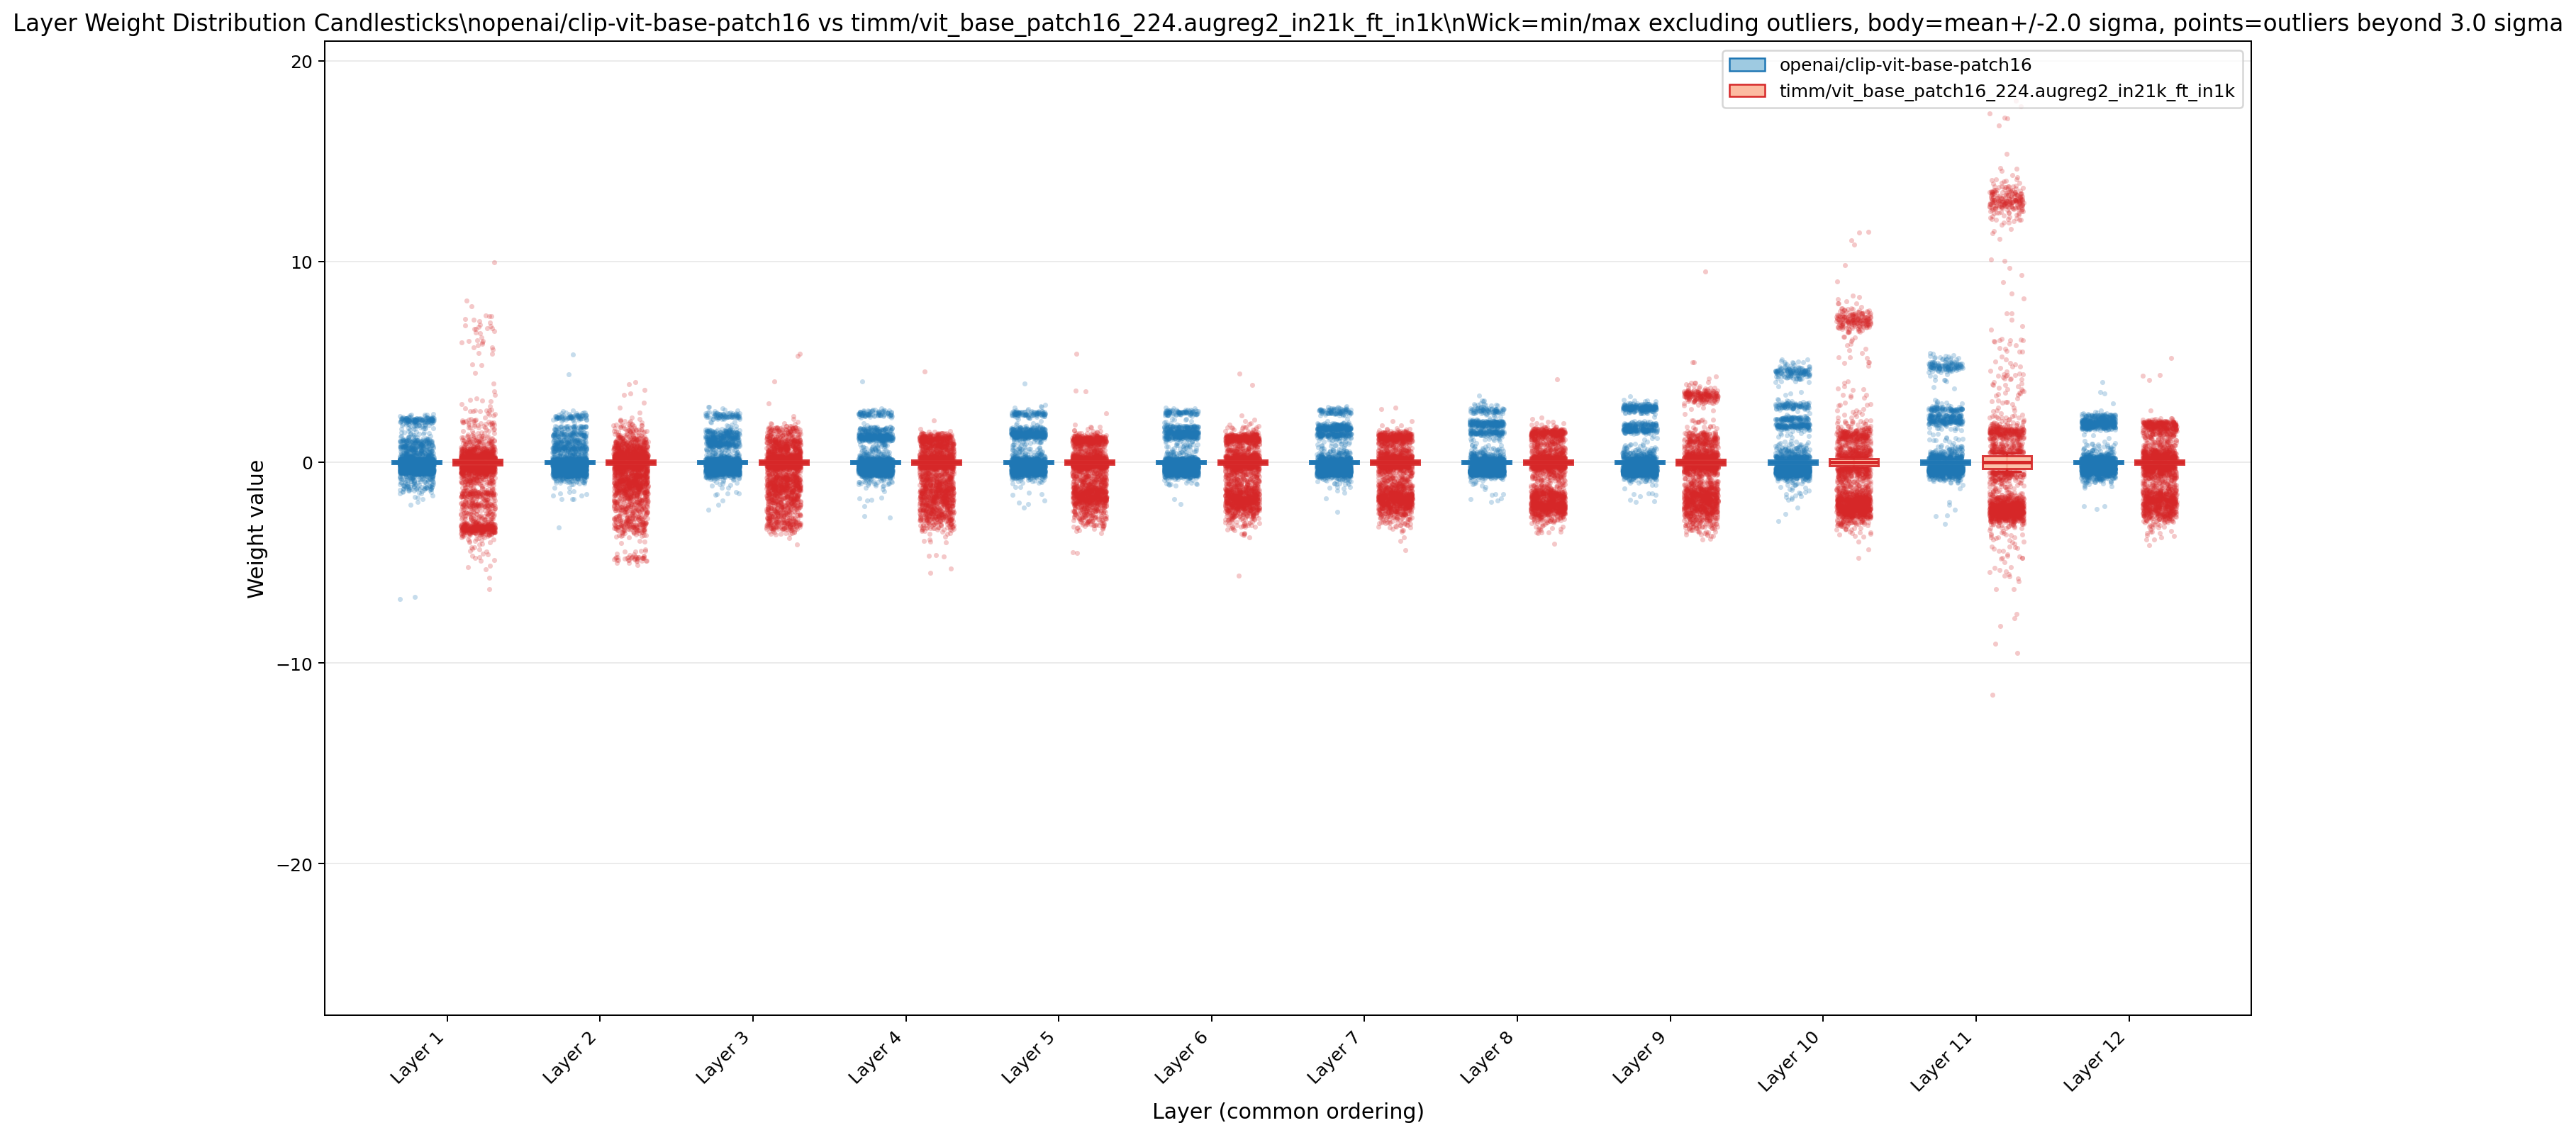

In [5]:
plot_weight_candlesticks(
    stats_a=layer_stats_a,
    stats_b=layer_stats_b,
    model_a_name=MODEL_A,
    model_b_name=MODEL_B,
    ordered_layer_indices=common_layer_indices,
)

## Granular view: component-by-component at each layer index

This compares matching component names at the same layer index (for example `attention` vs `attention`, `mlp` vs `mlp`).

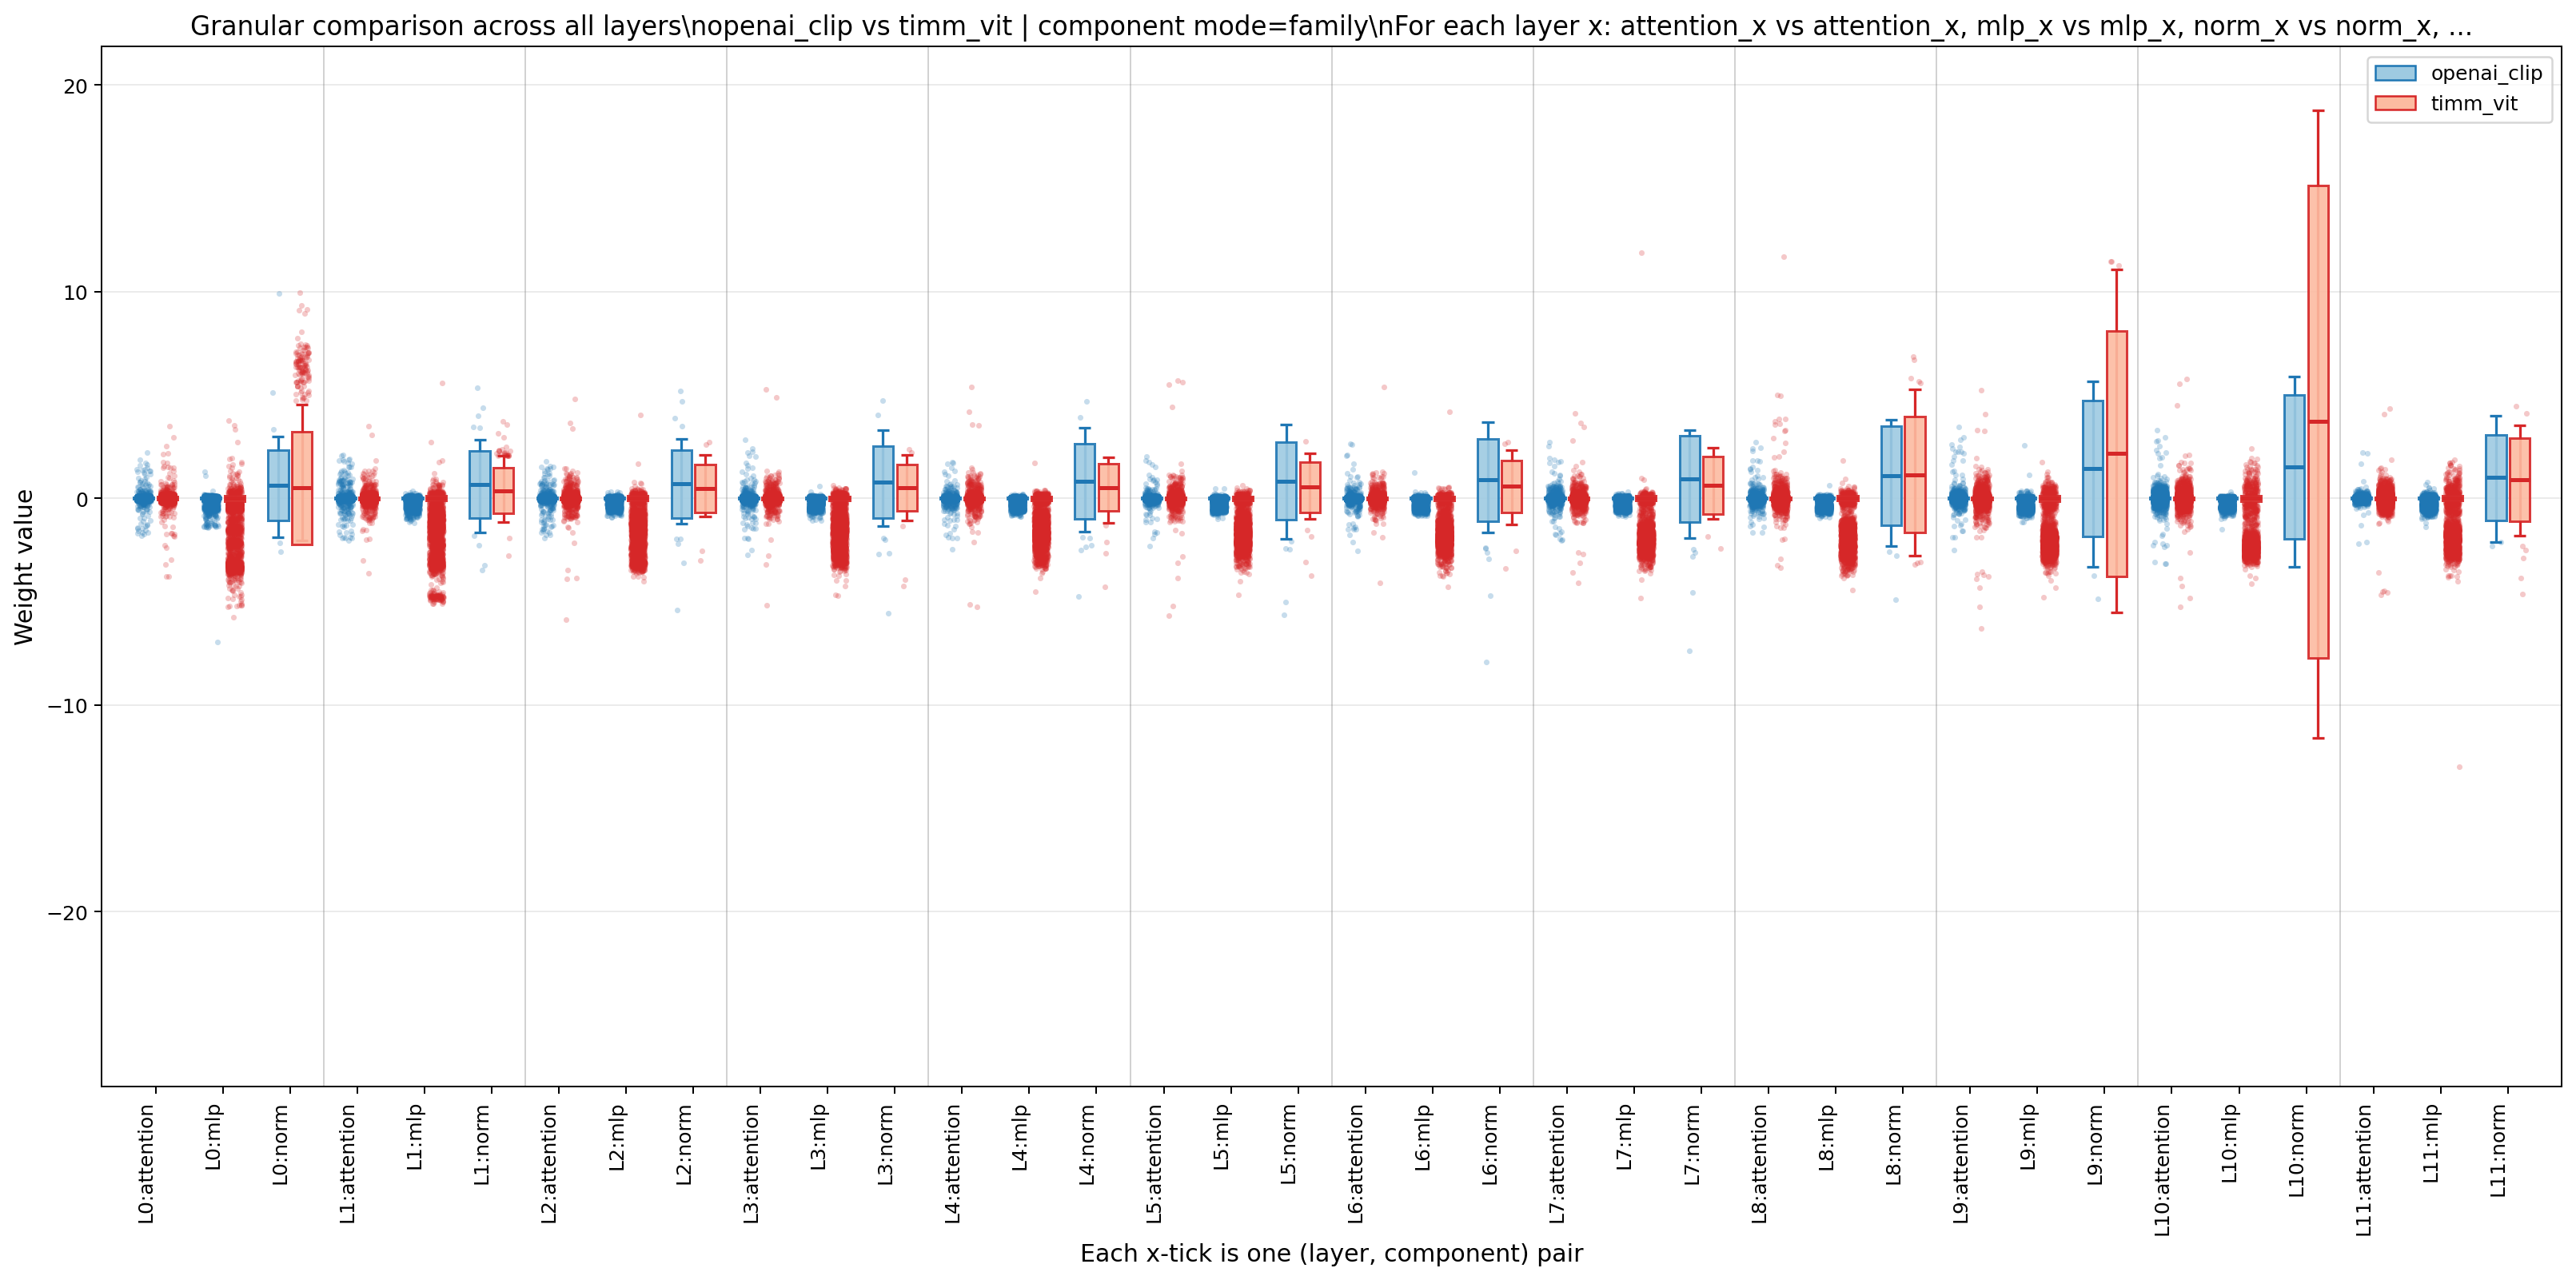

In [6]:
plot_component_candlesticks_across_layers(
    component_stats_a=component_stats_a,
    component_stats_b=component_stats_b,
    model_a_name=MODEL_A_LABEL,
    model_b_name=MODEL_B_LABEL,
    ordered_layer_indices=common_layer_indices,
)

Granular layer indices available: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Plotting granular view for layer index 0 with 3 common components


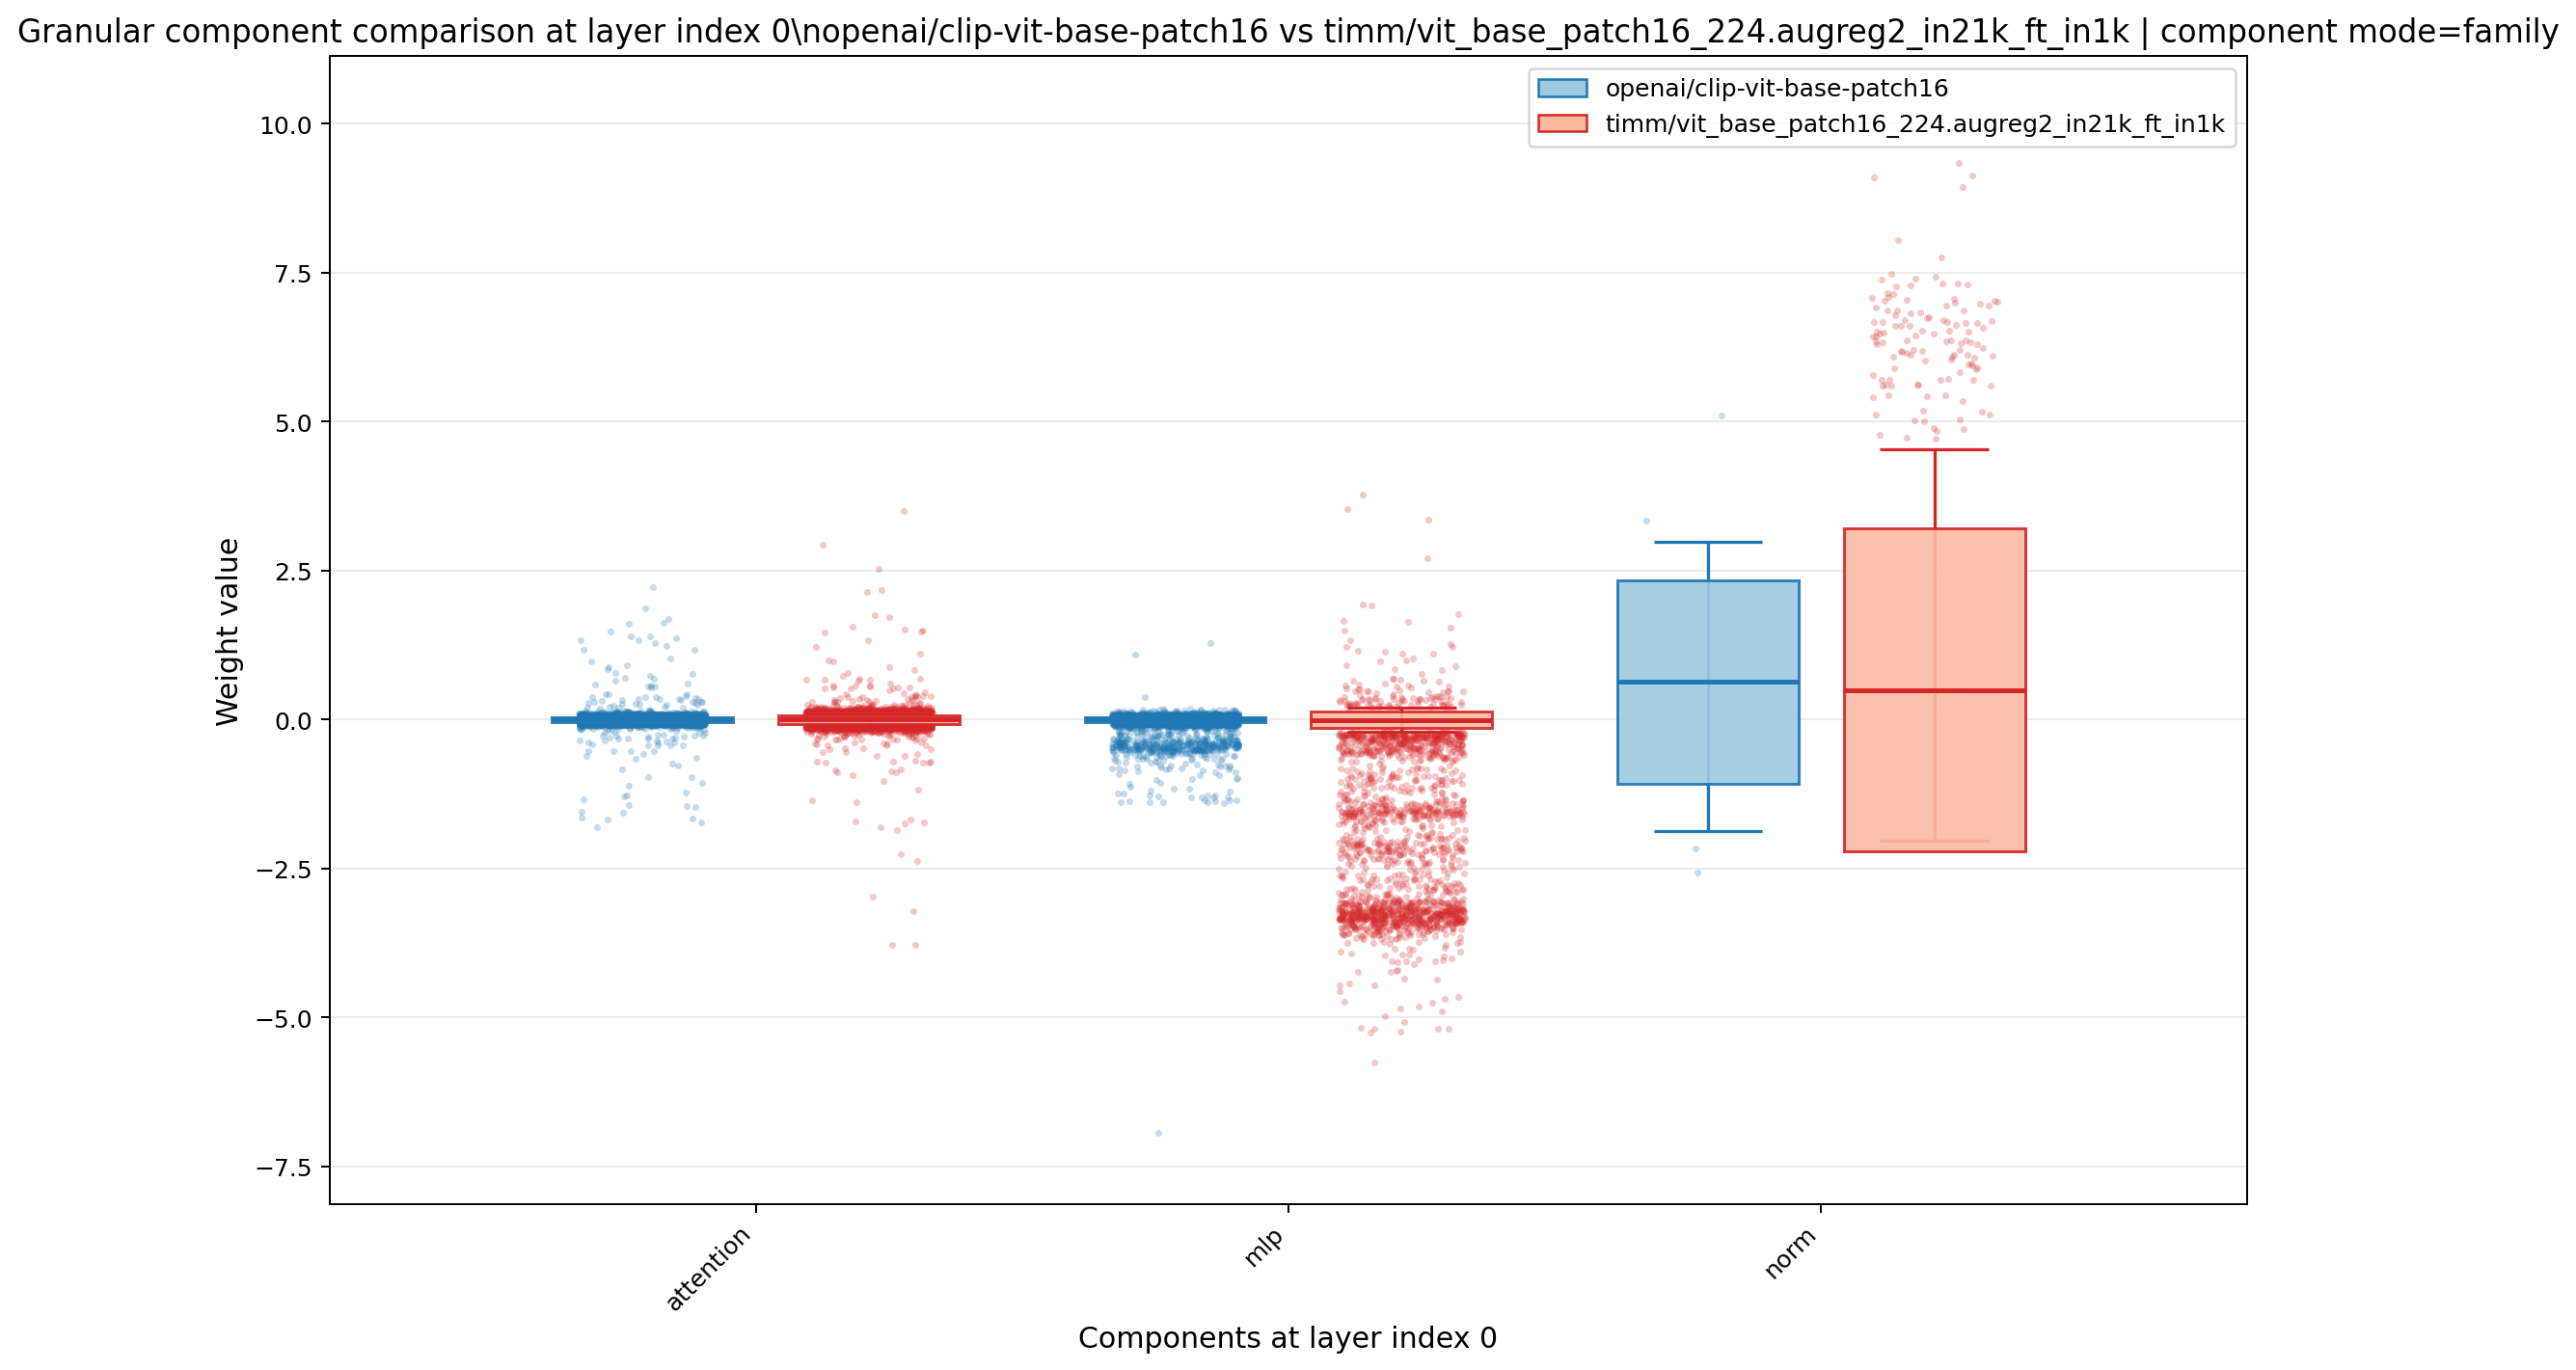

Plotting granular view for layer index 1 with 3 common components


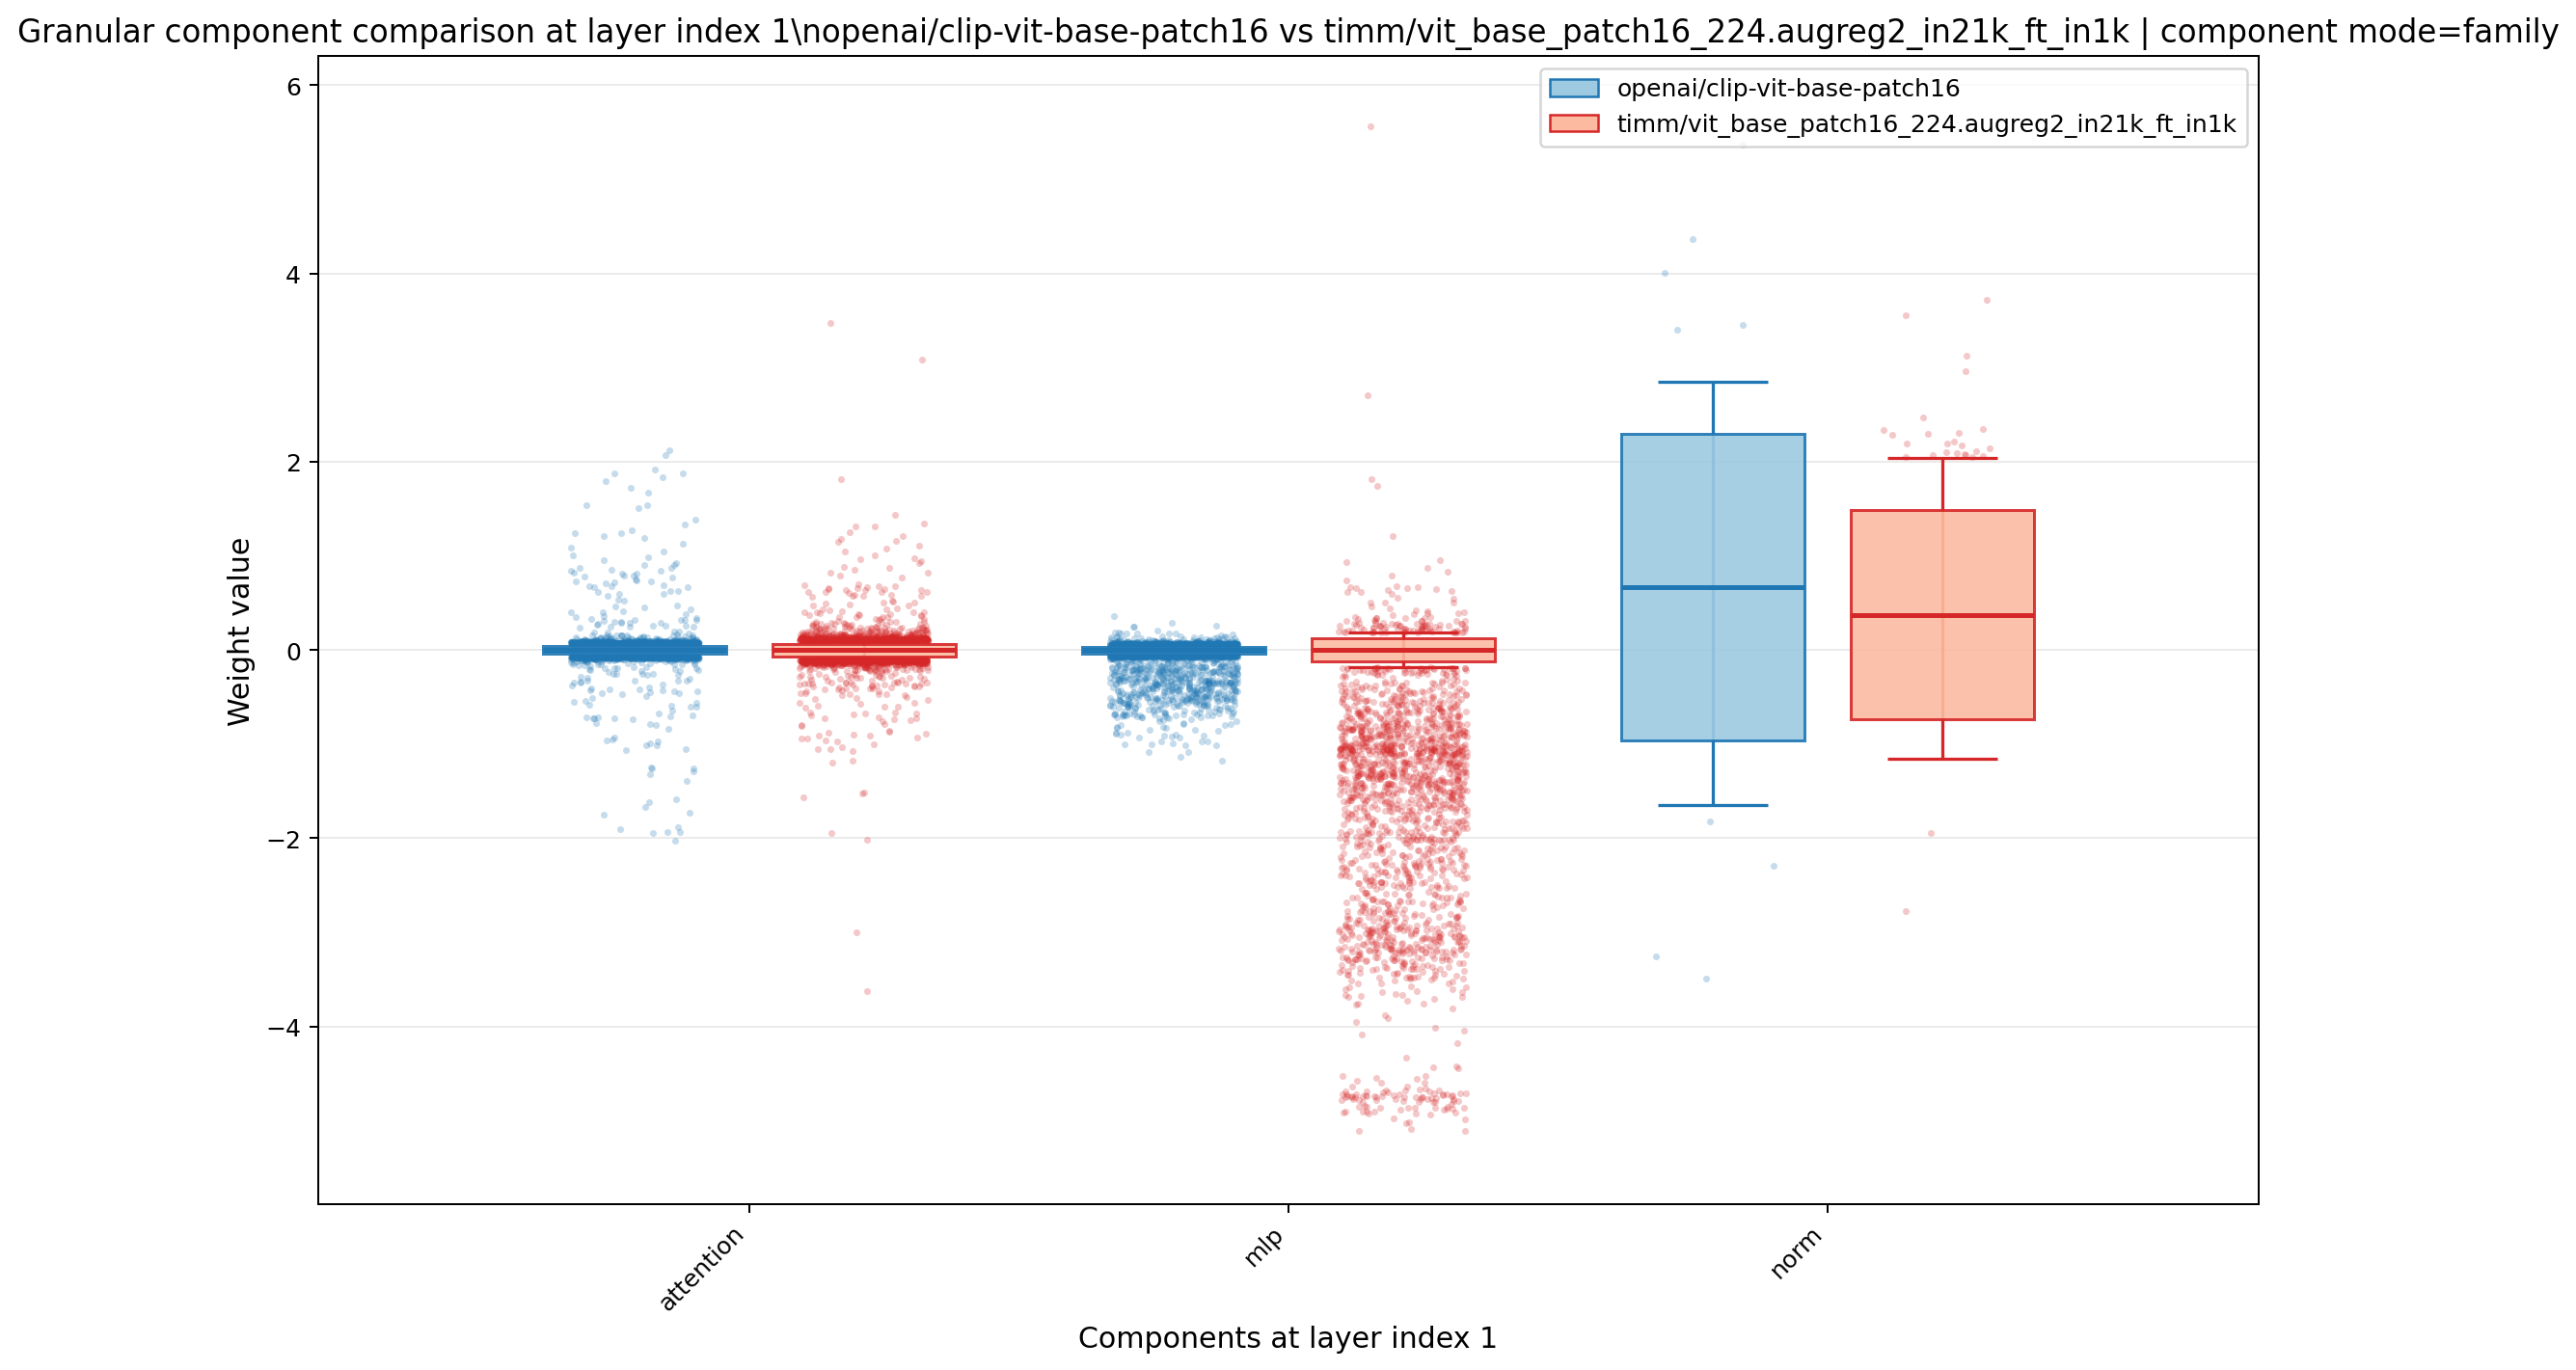

Plotting granular view for layer index 2 with 3 common components


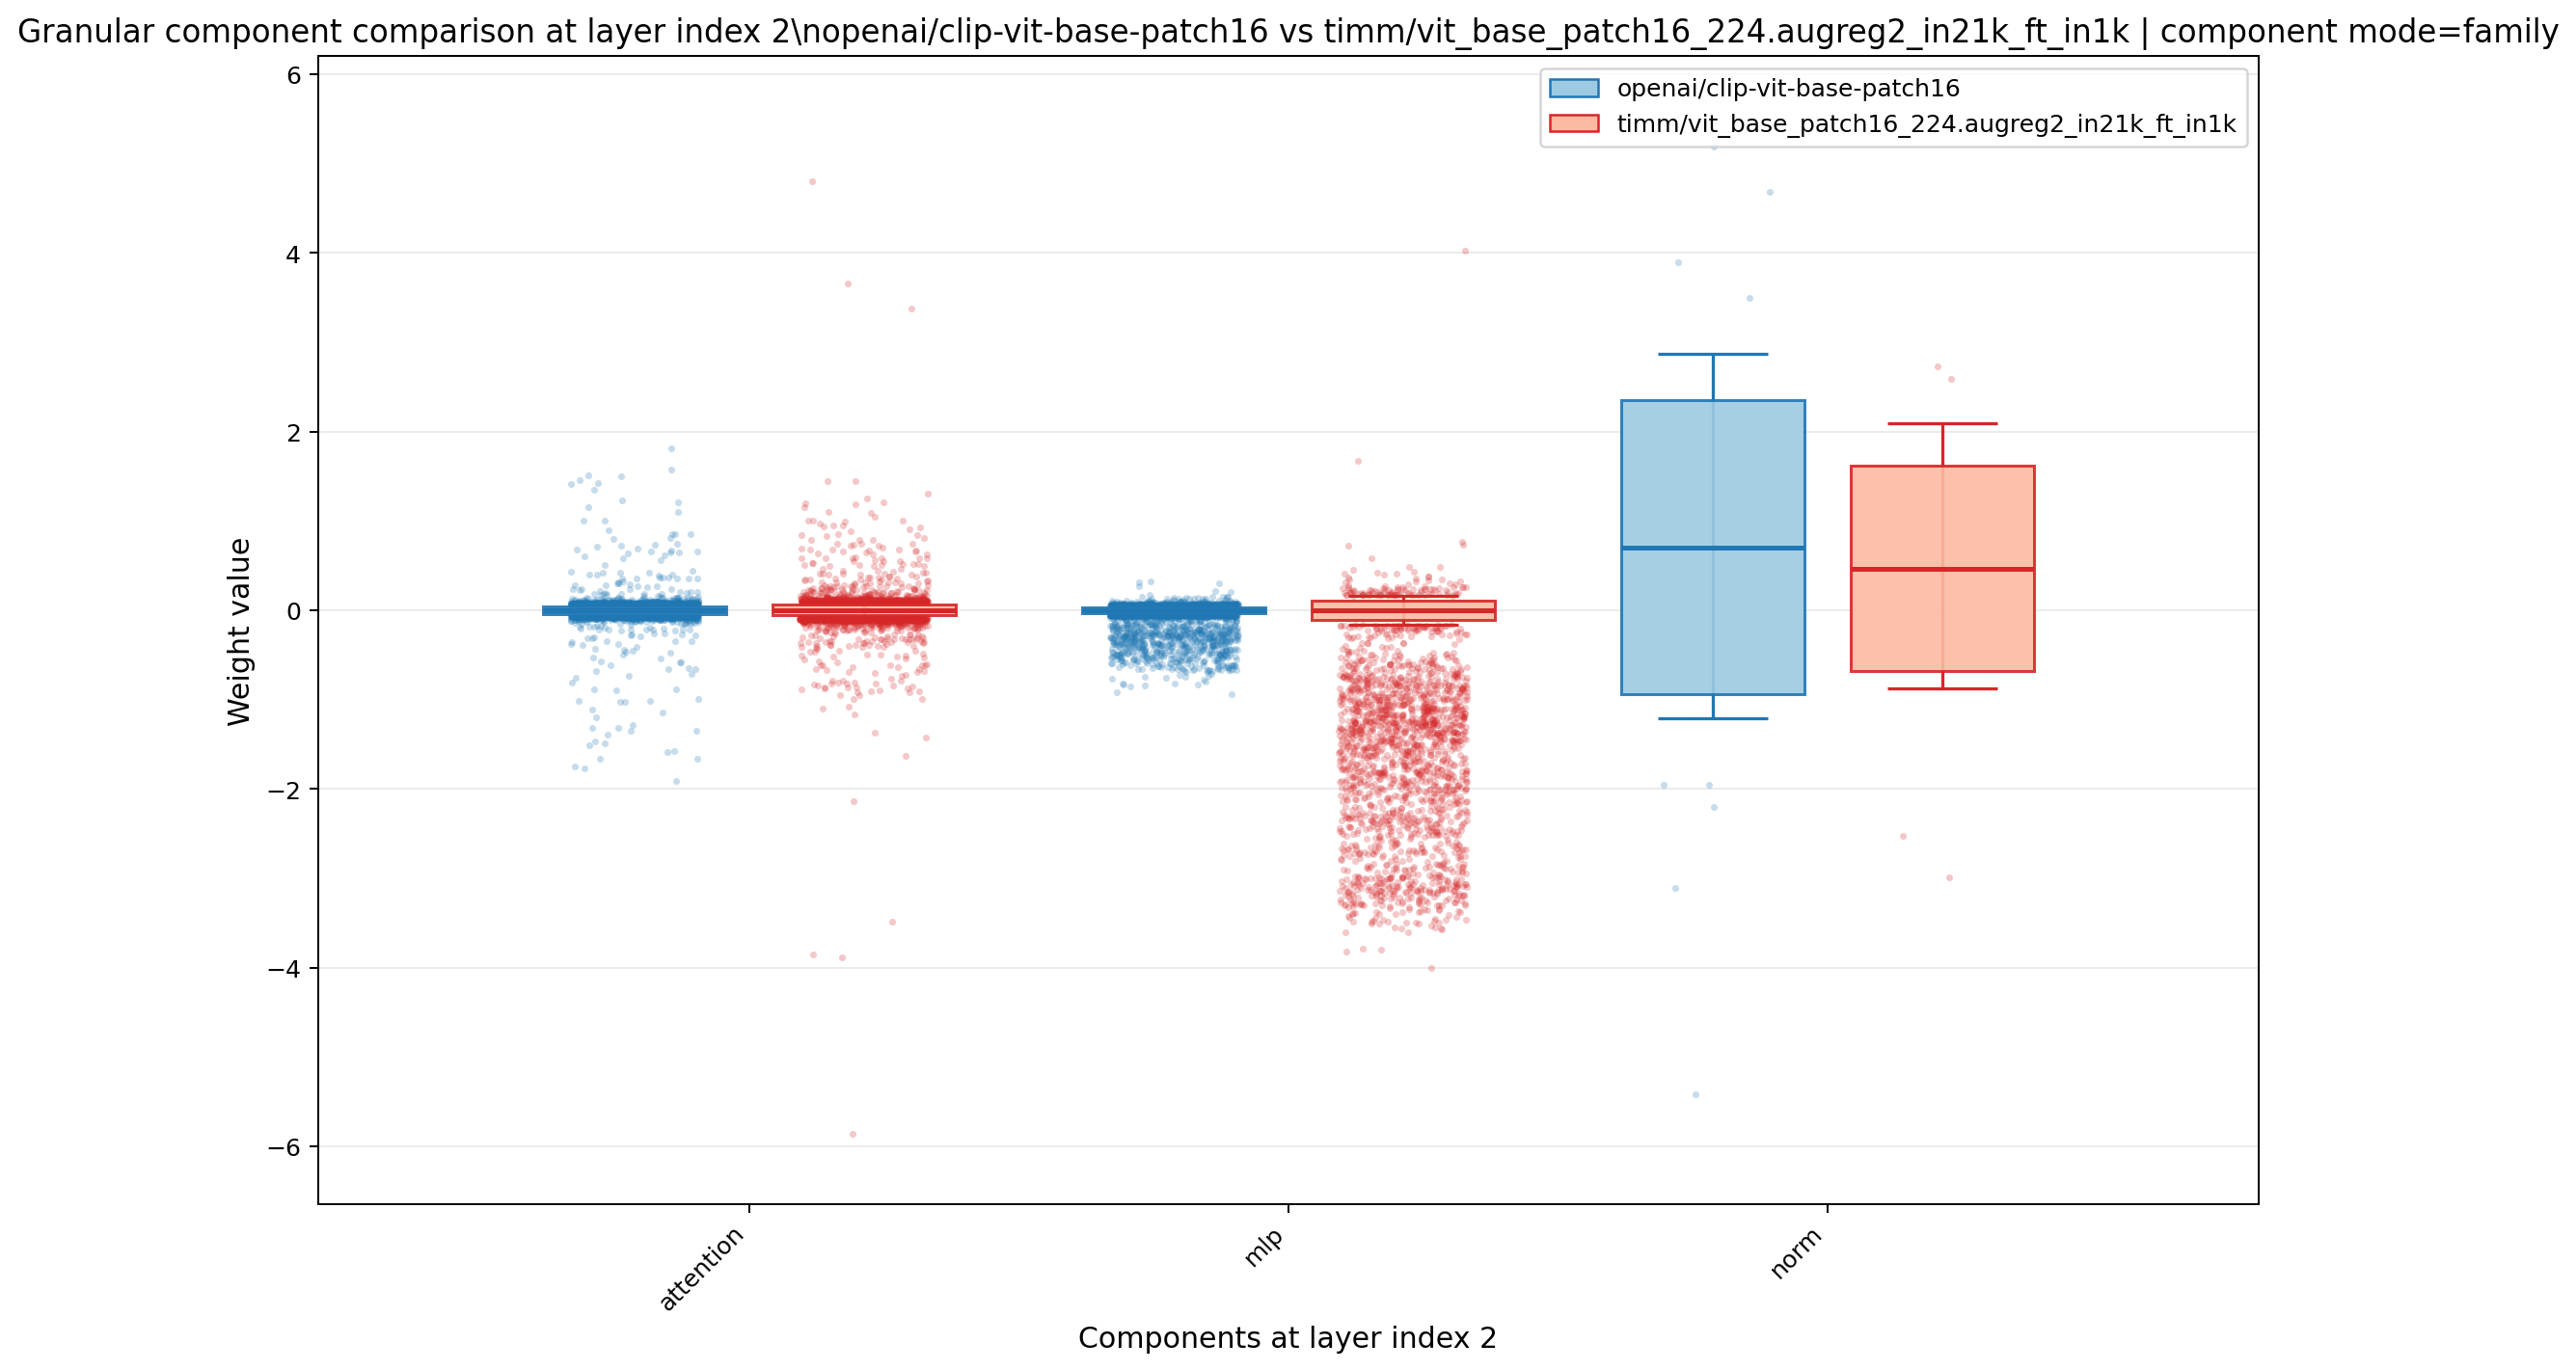

Plotting granular view for layer index 3 with 3 common components


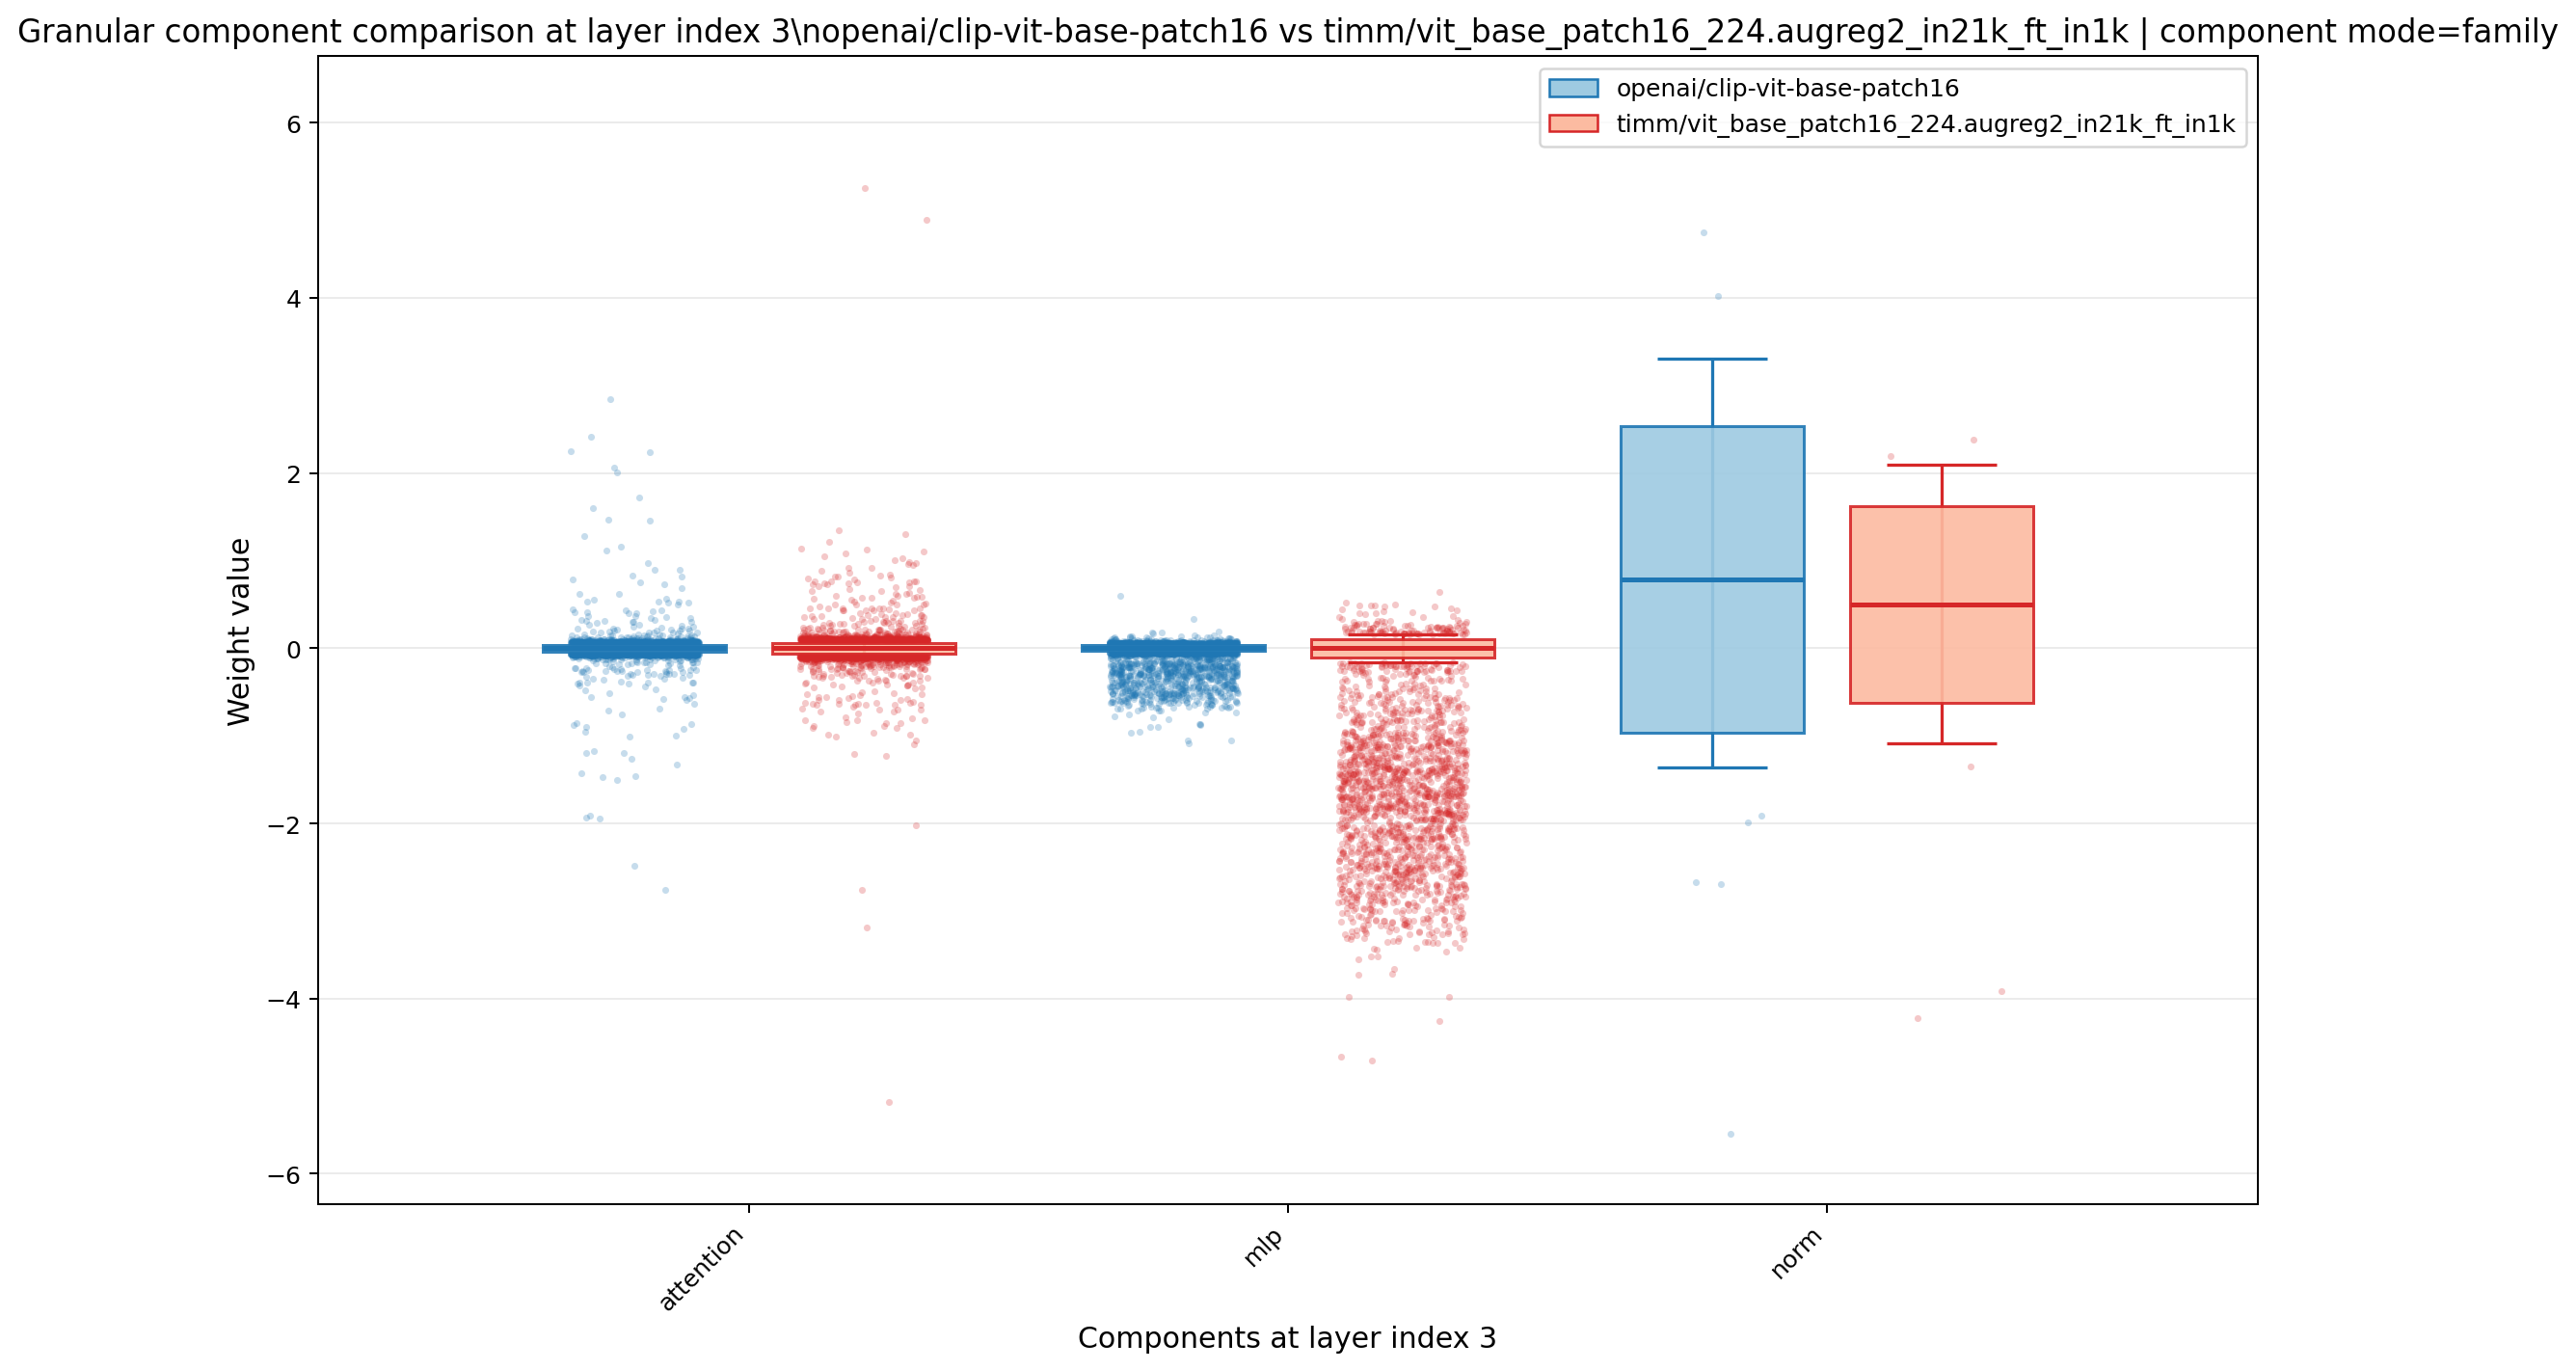

Plotting granular view for layer index 4 with 3 common components


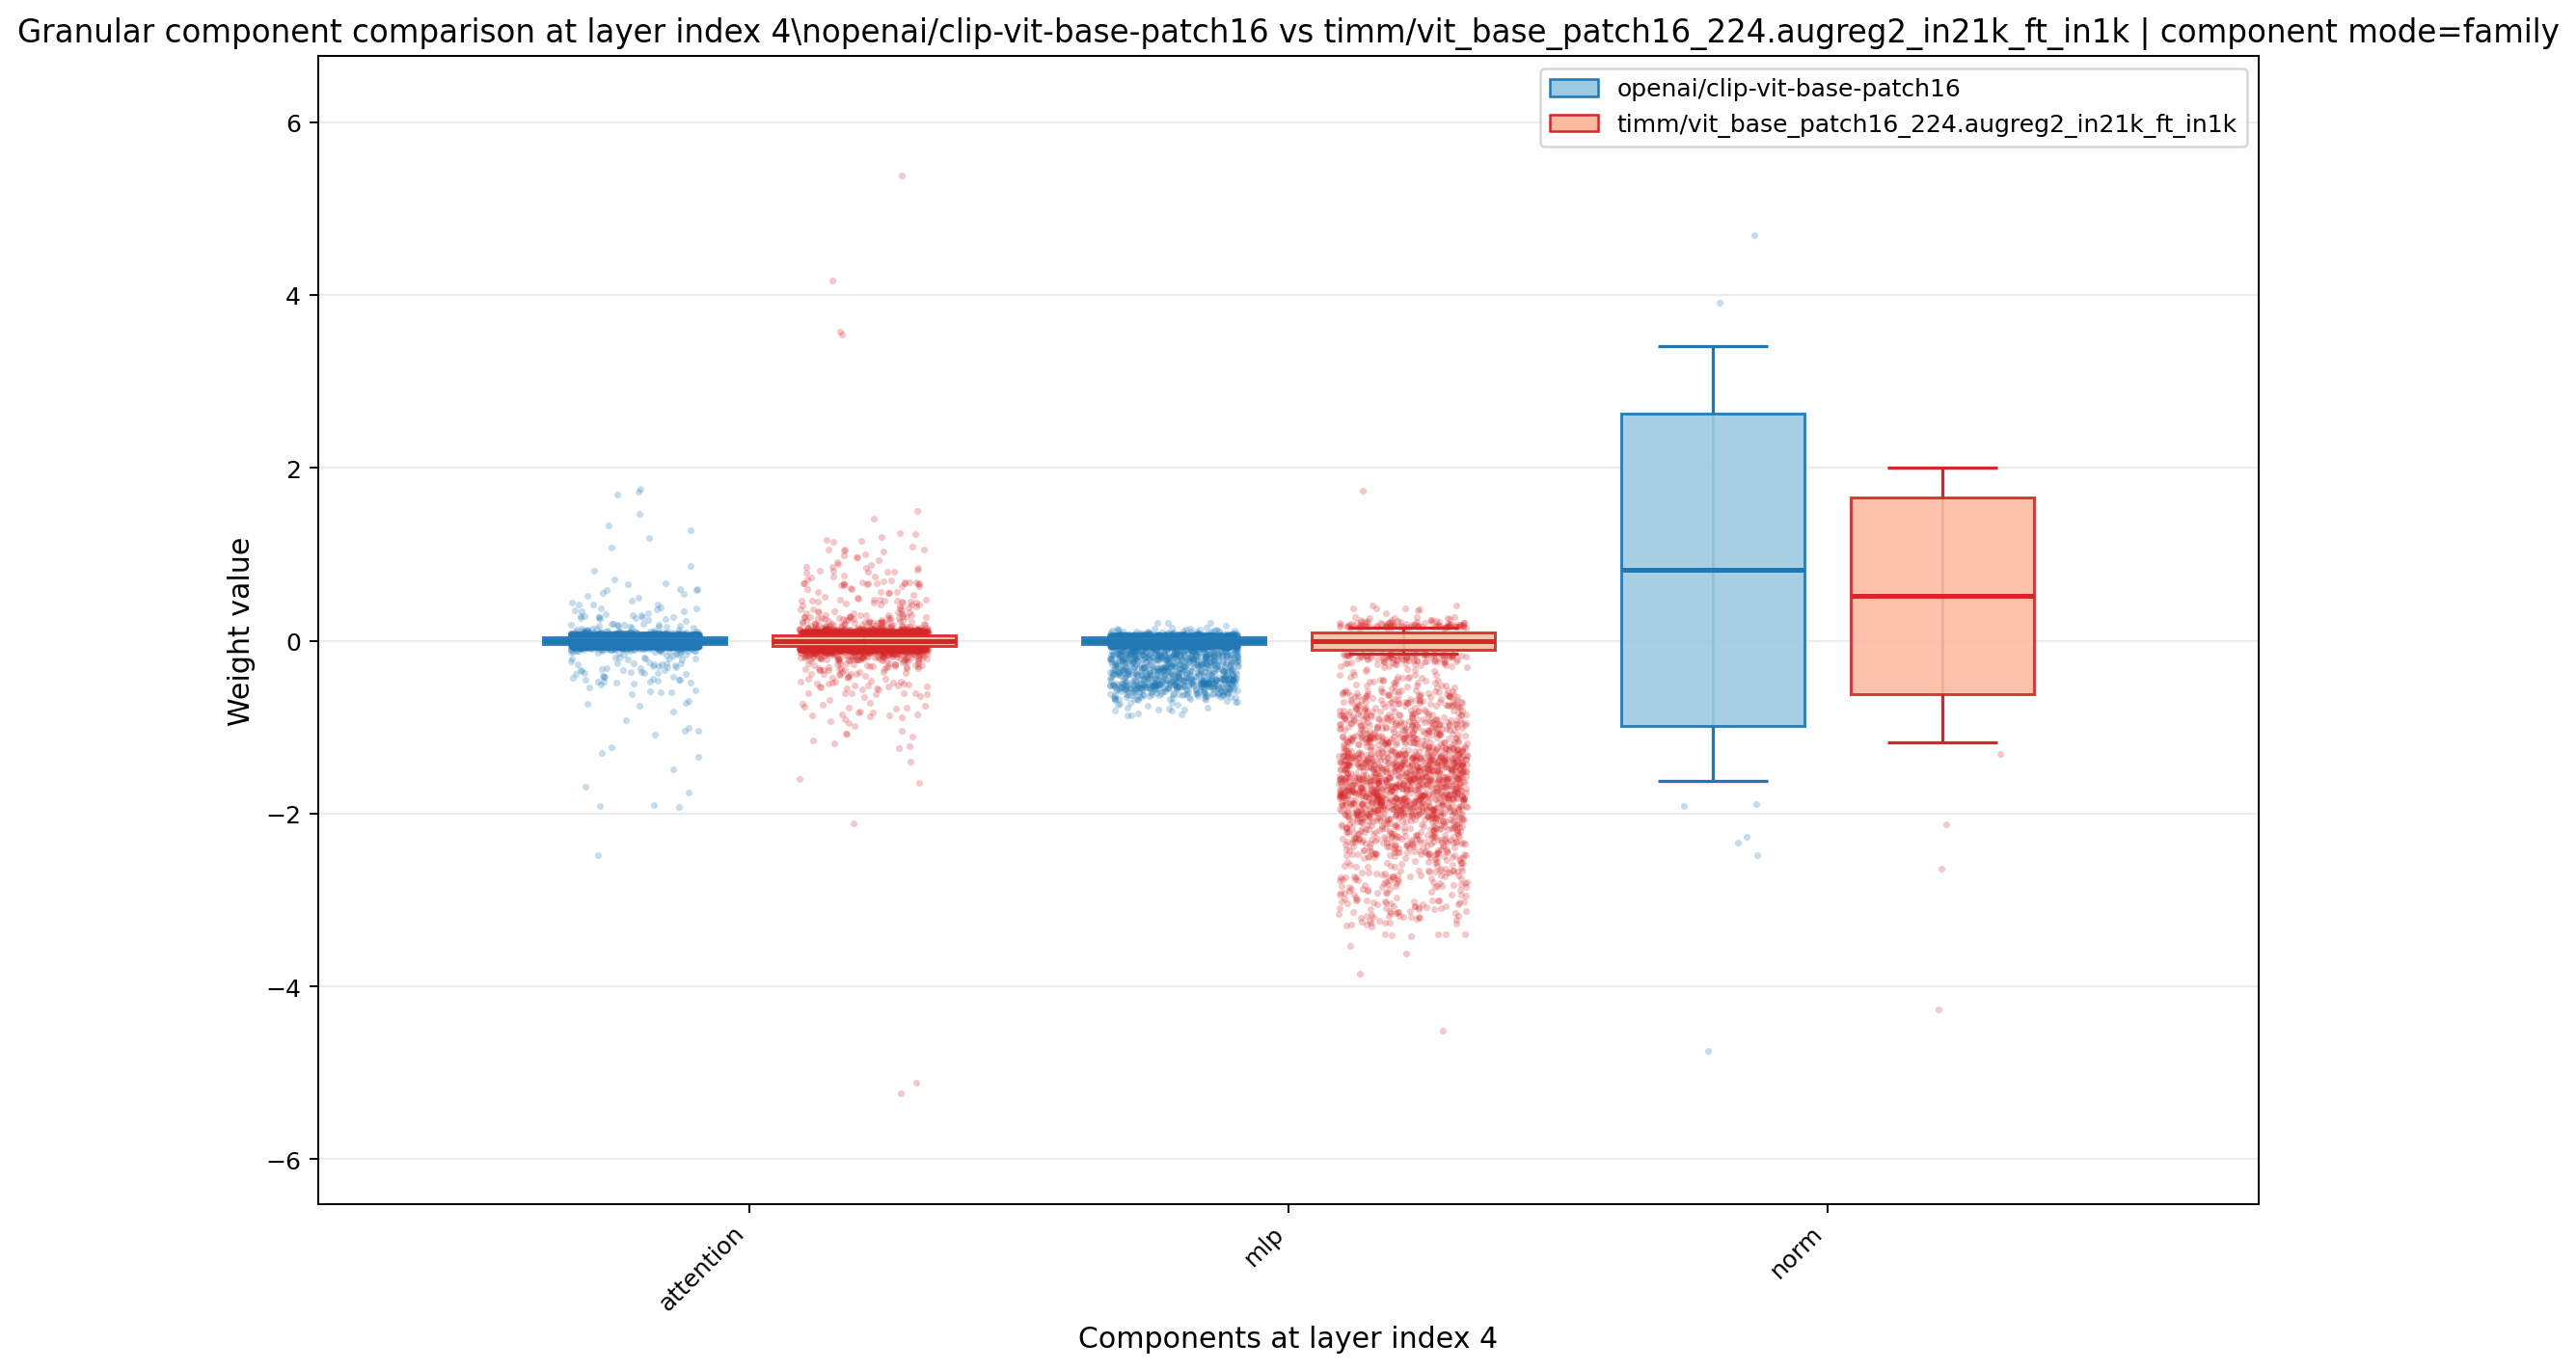

Plotting granular view for layer index 5 with 3 common components


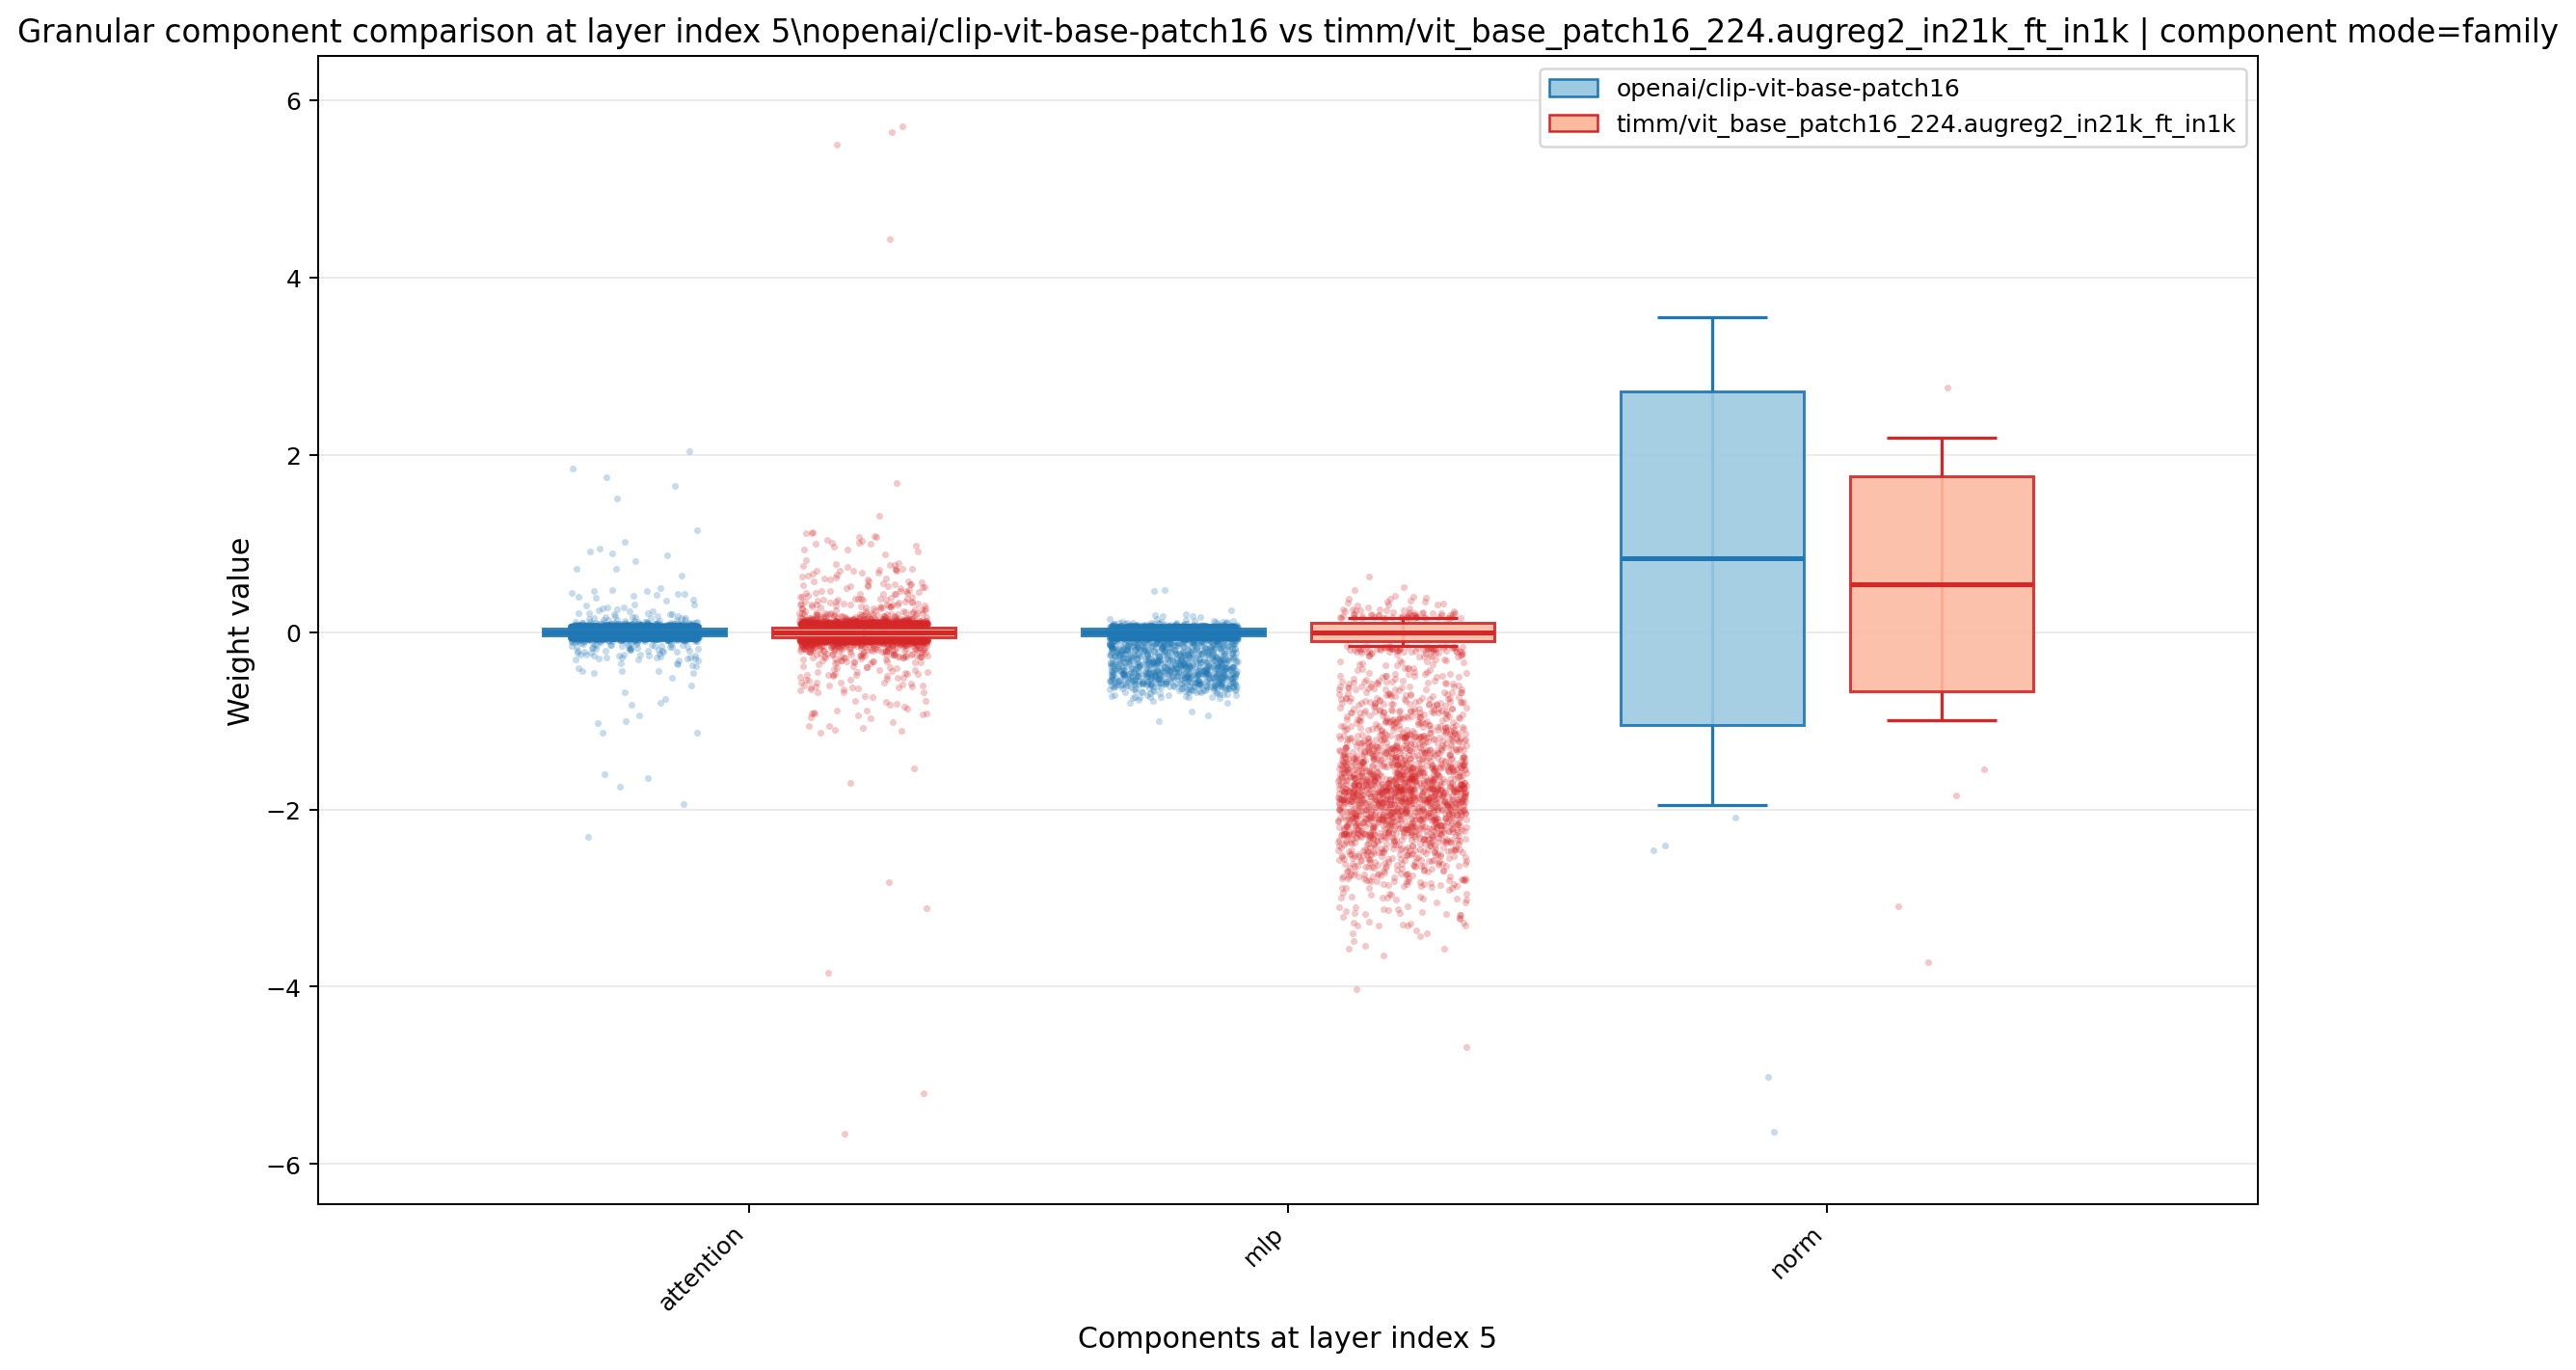

Plotting granular view for layer index 6 with 3 common components


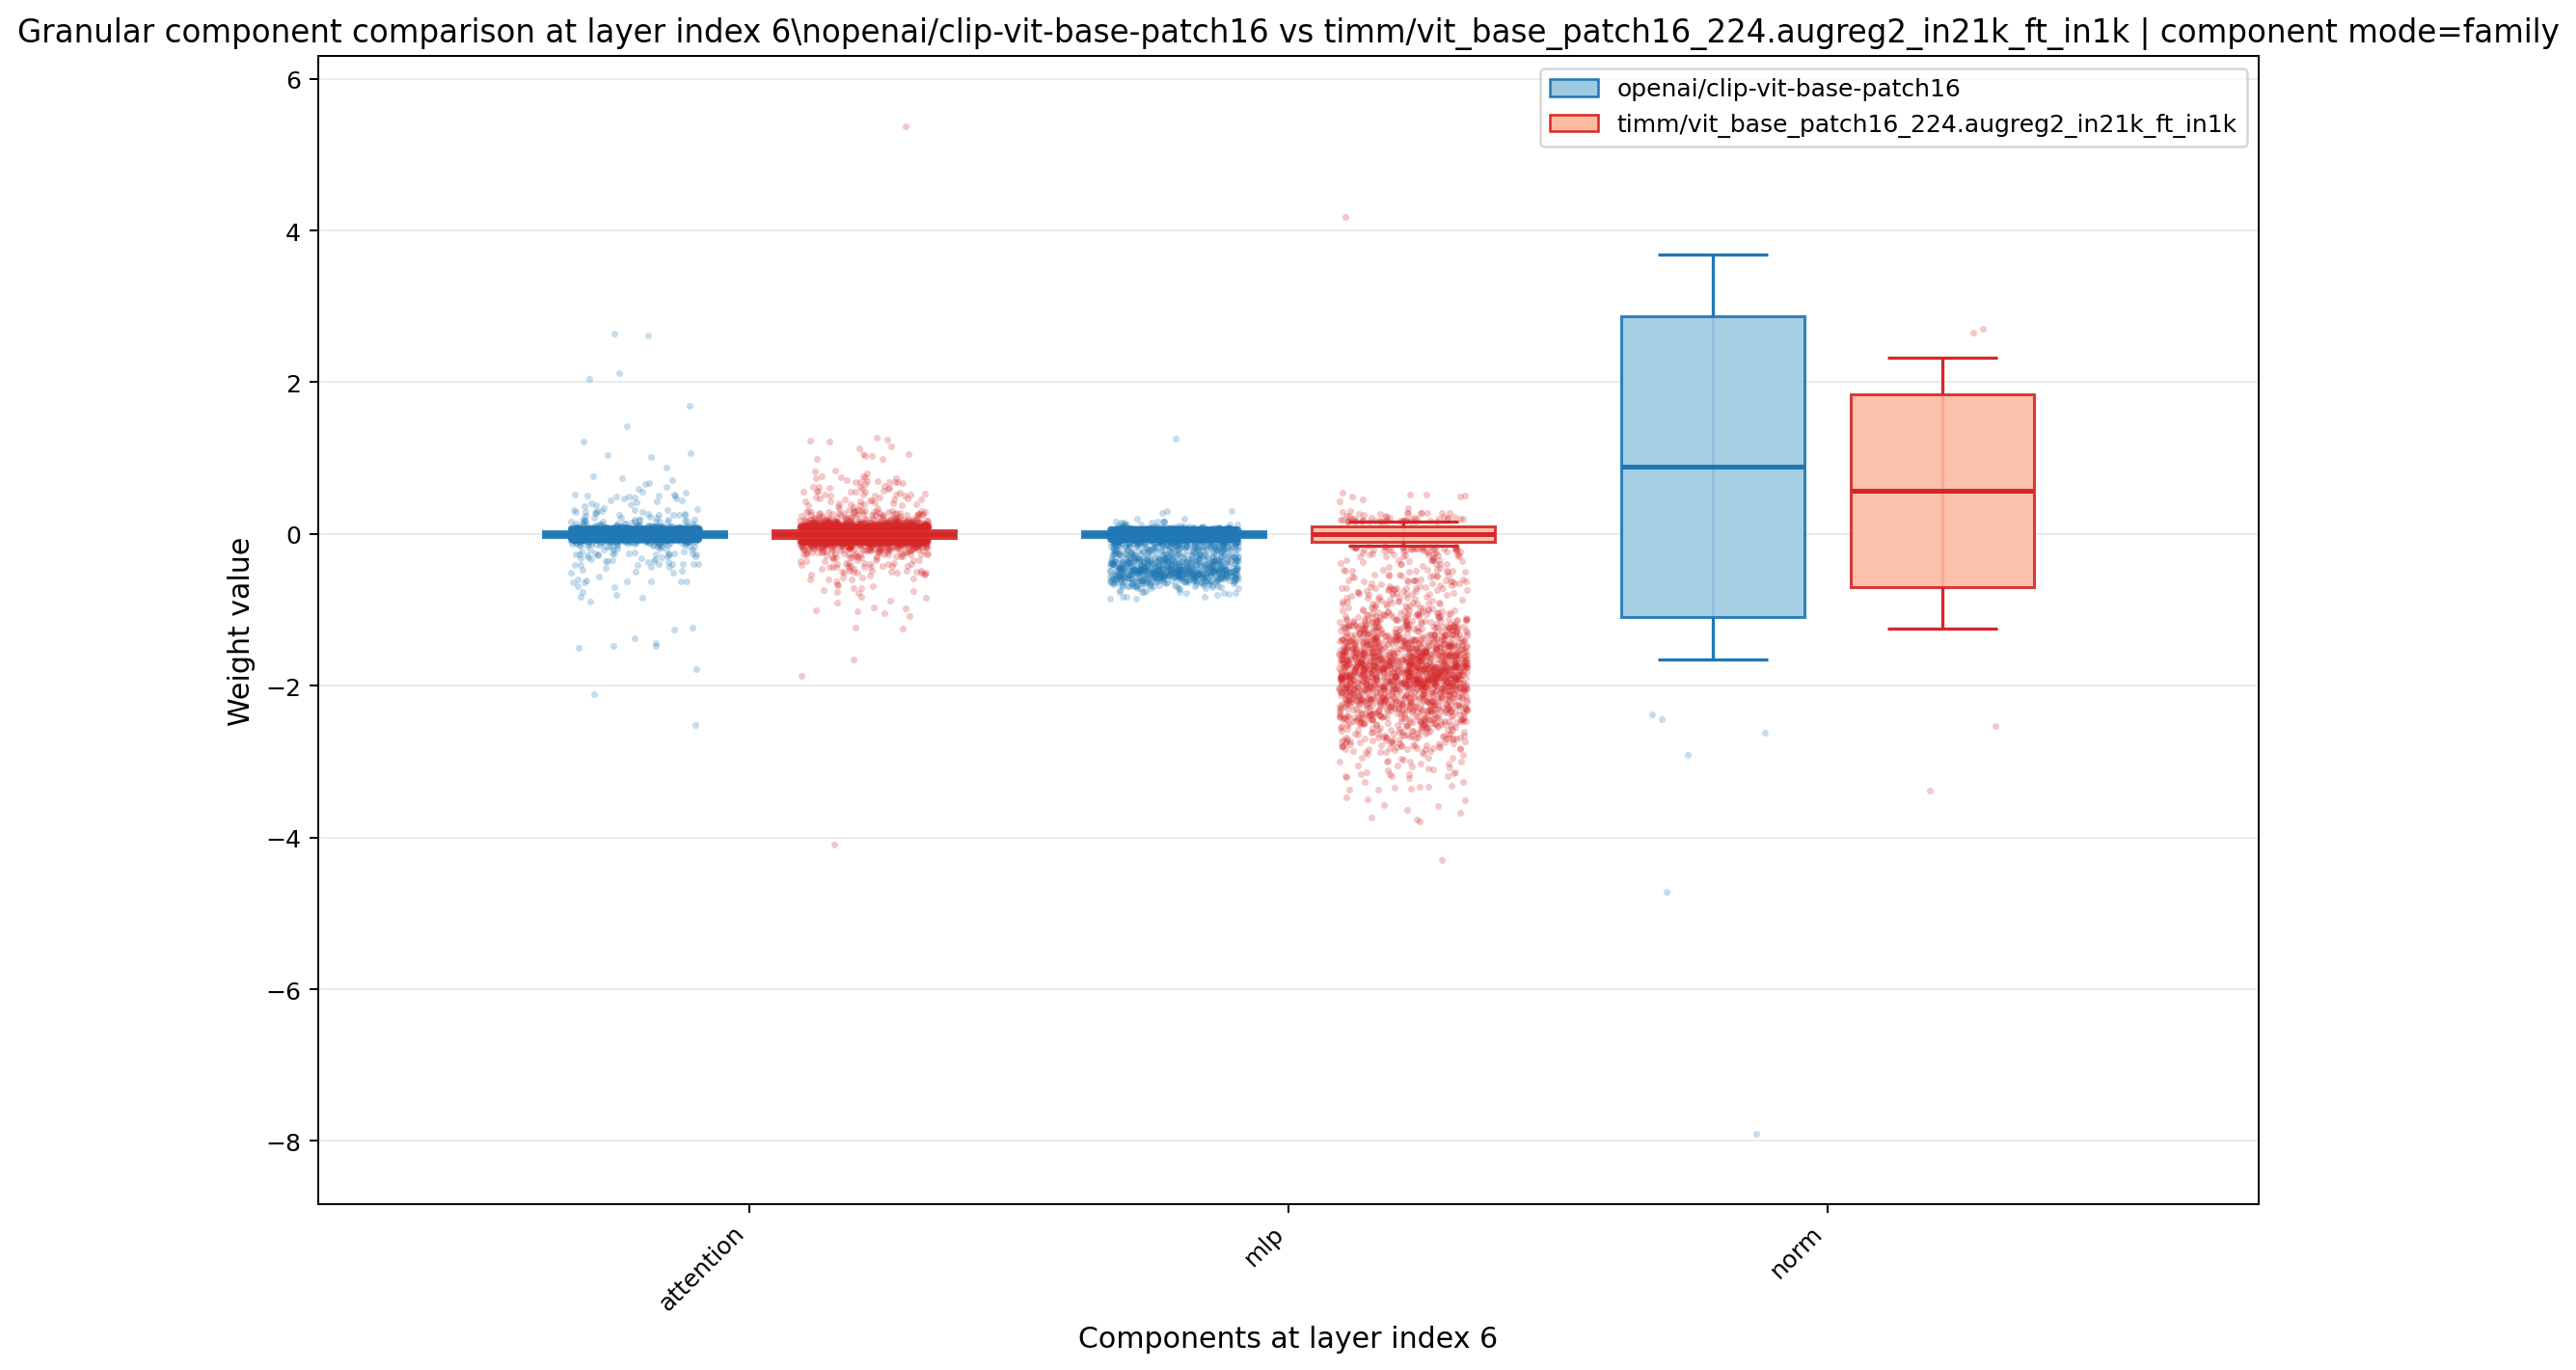

Plotting granular view for layer index 7 with 3 common components


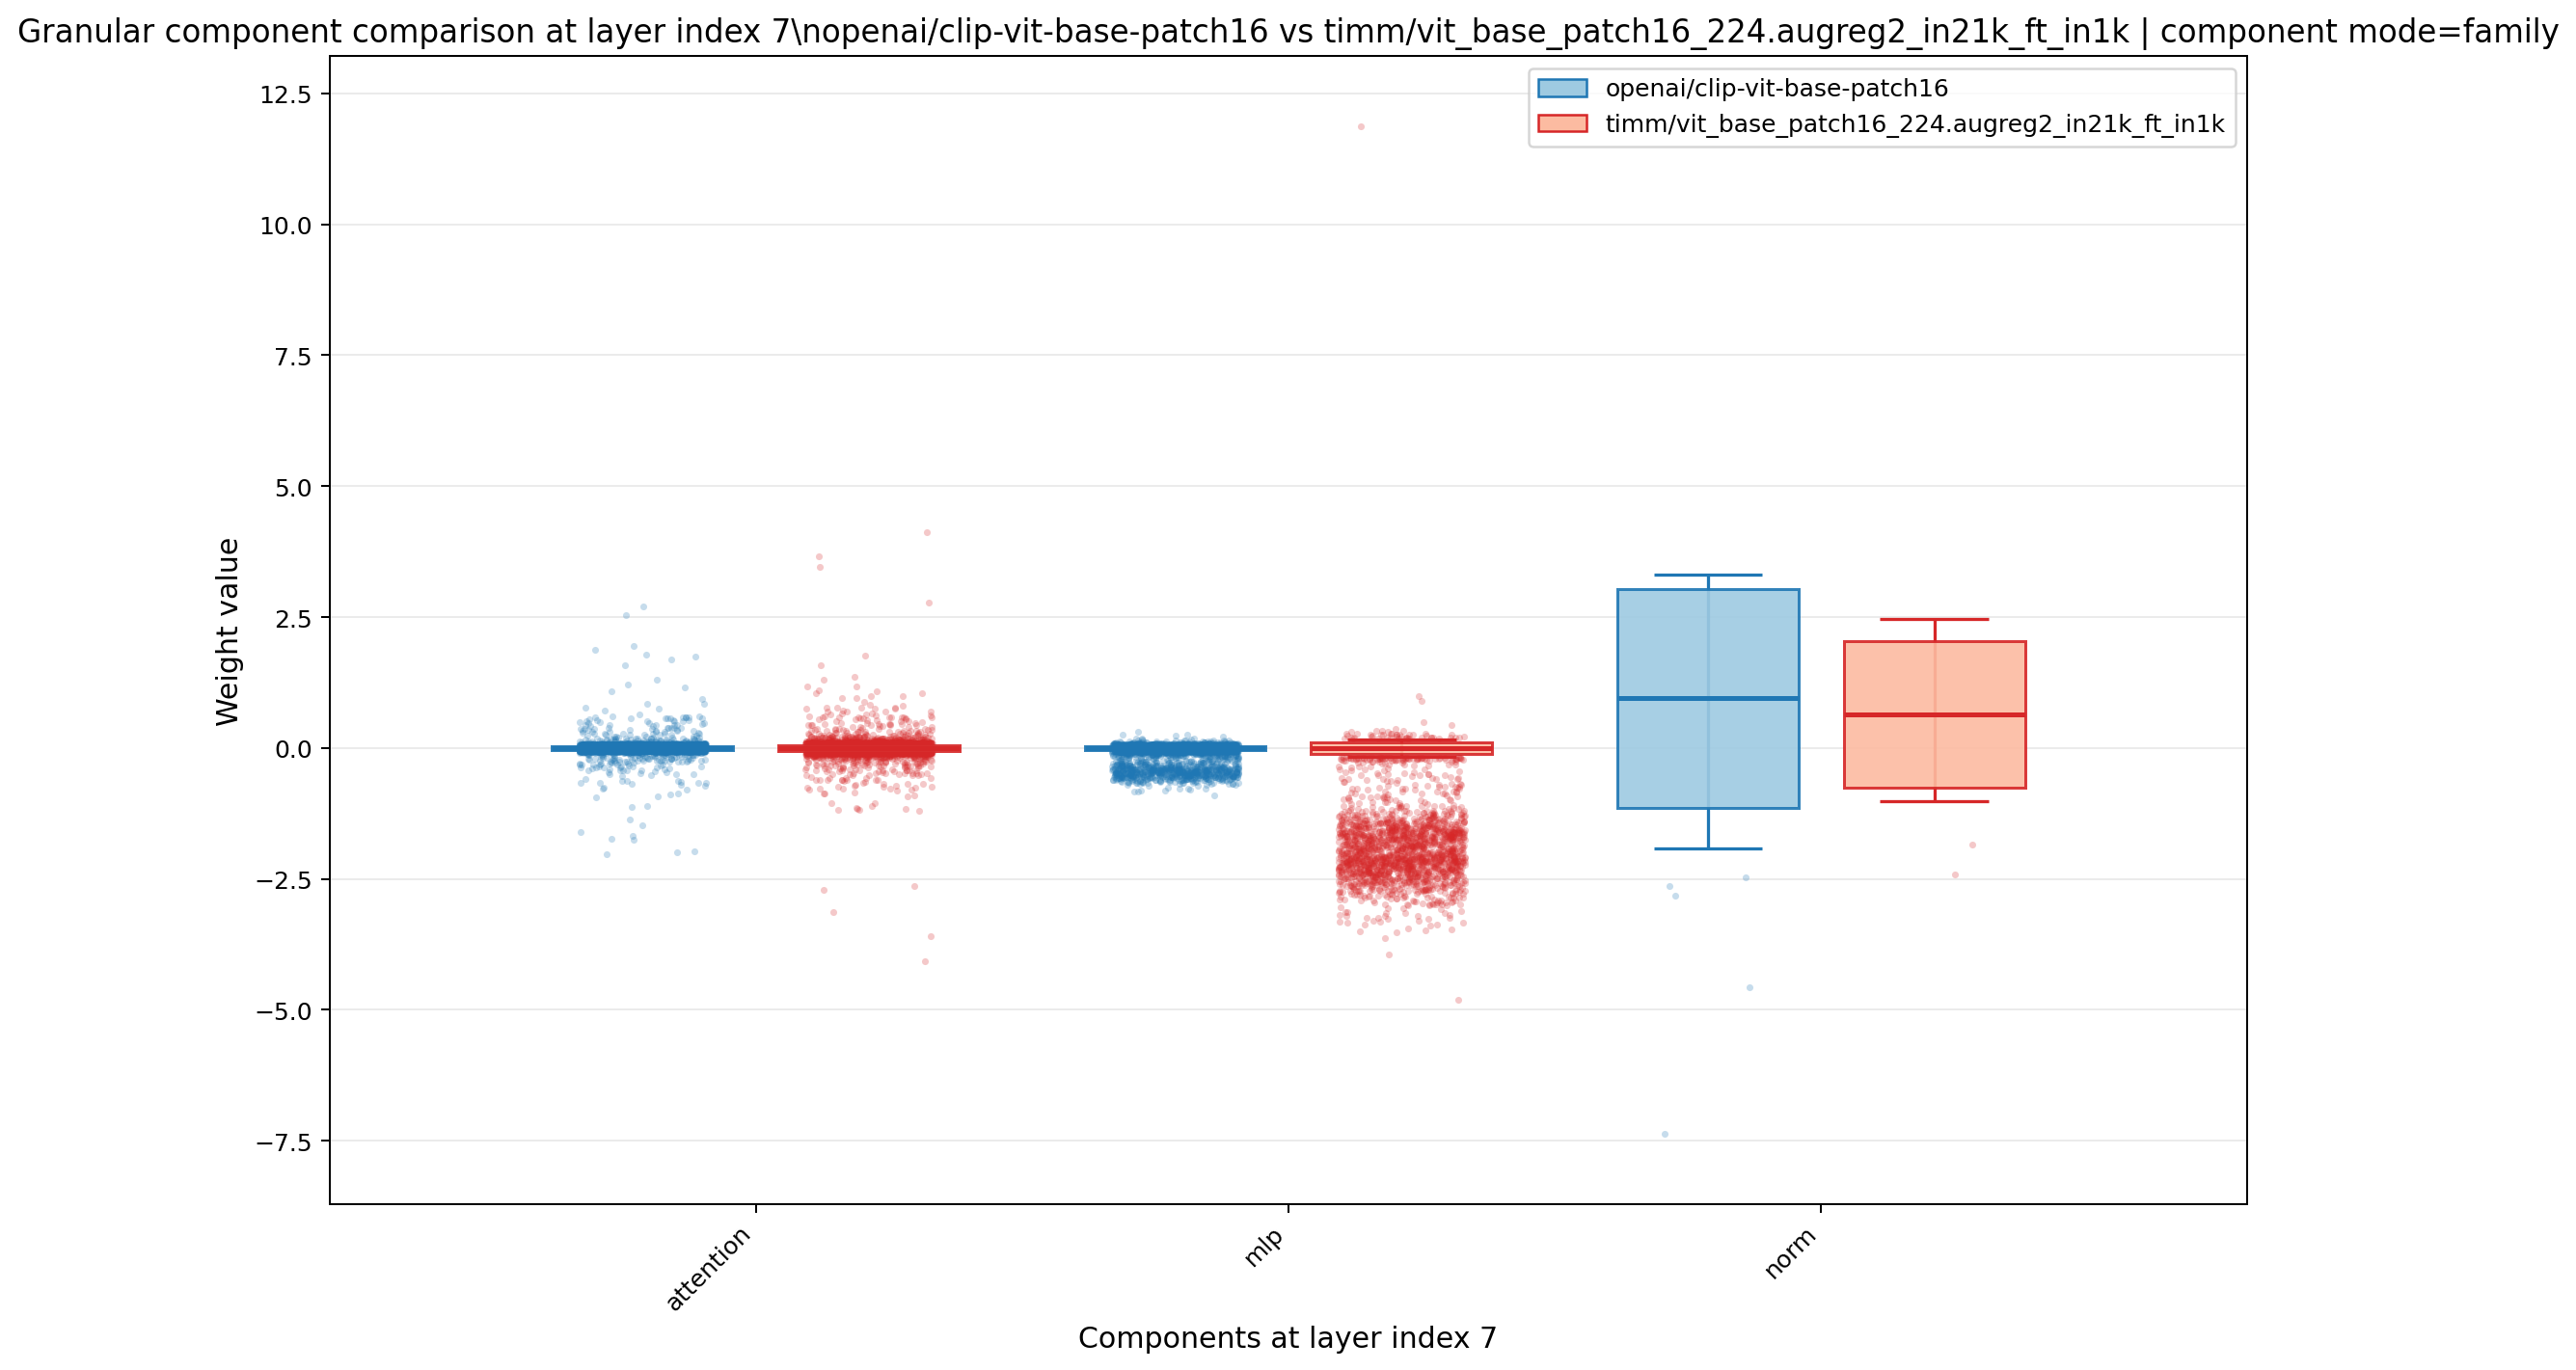

Plotting granular view for layer index 8 with 3 common components


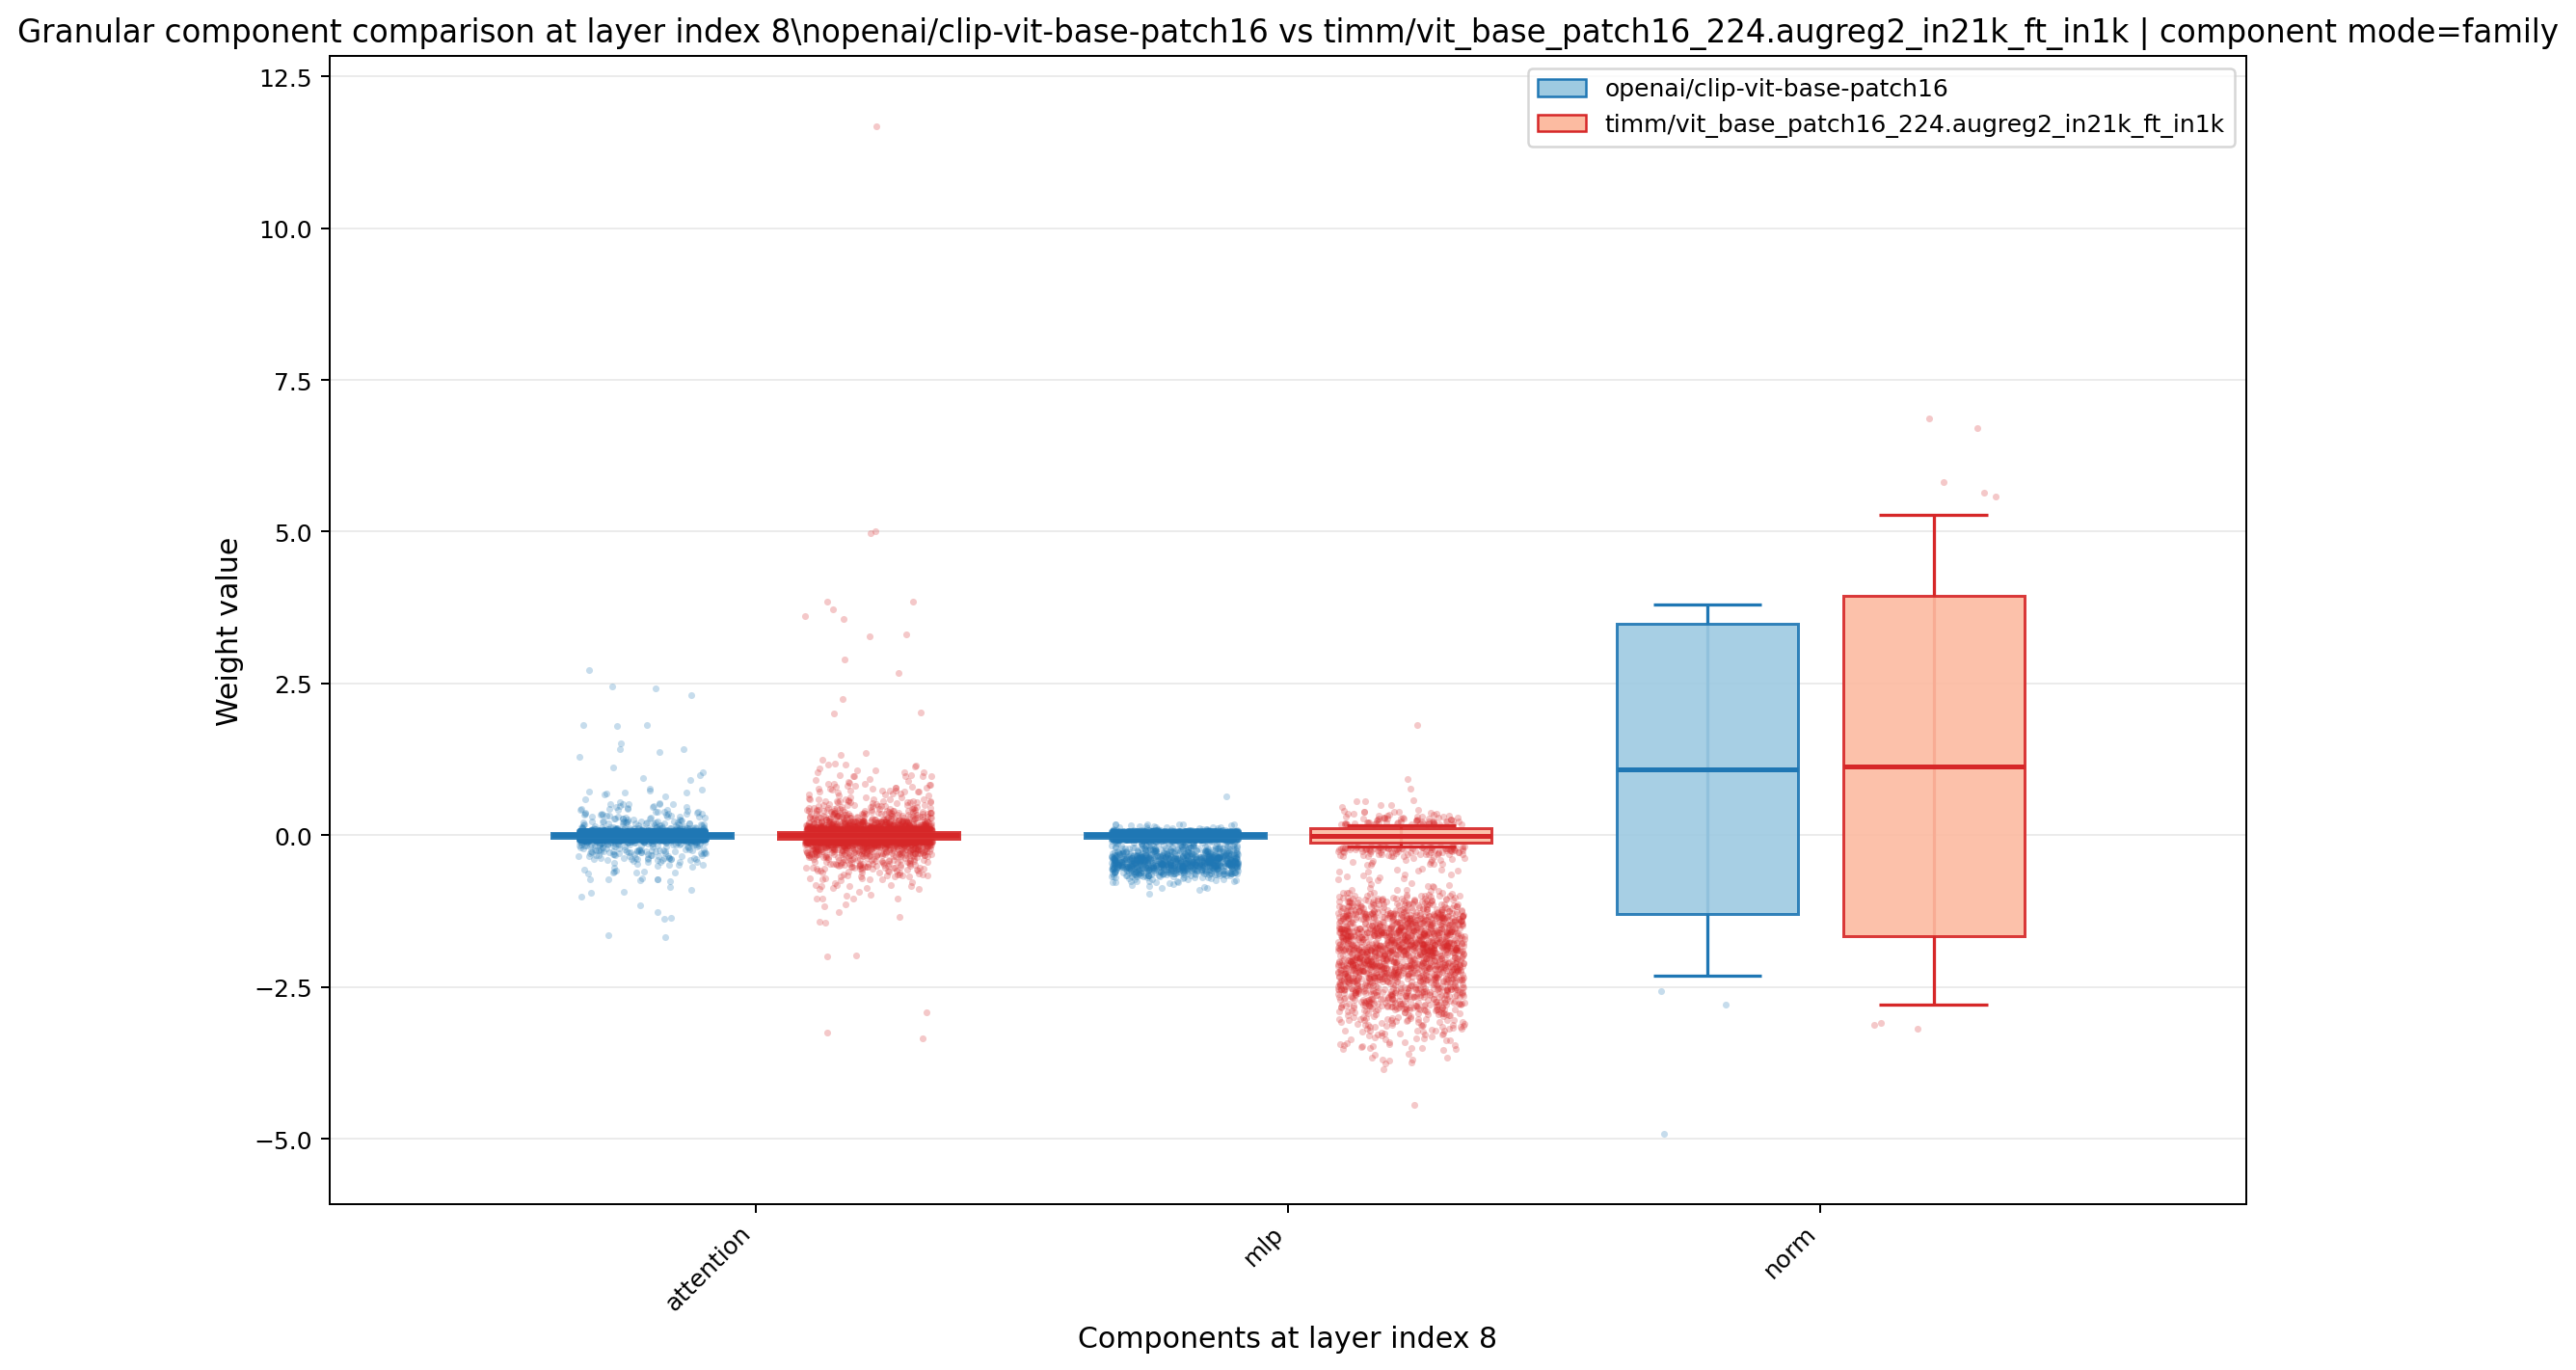

Plotting granular view for layer index 9 with 3 common components


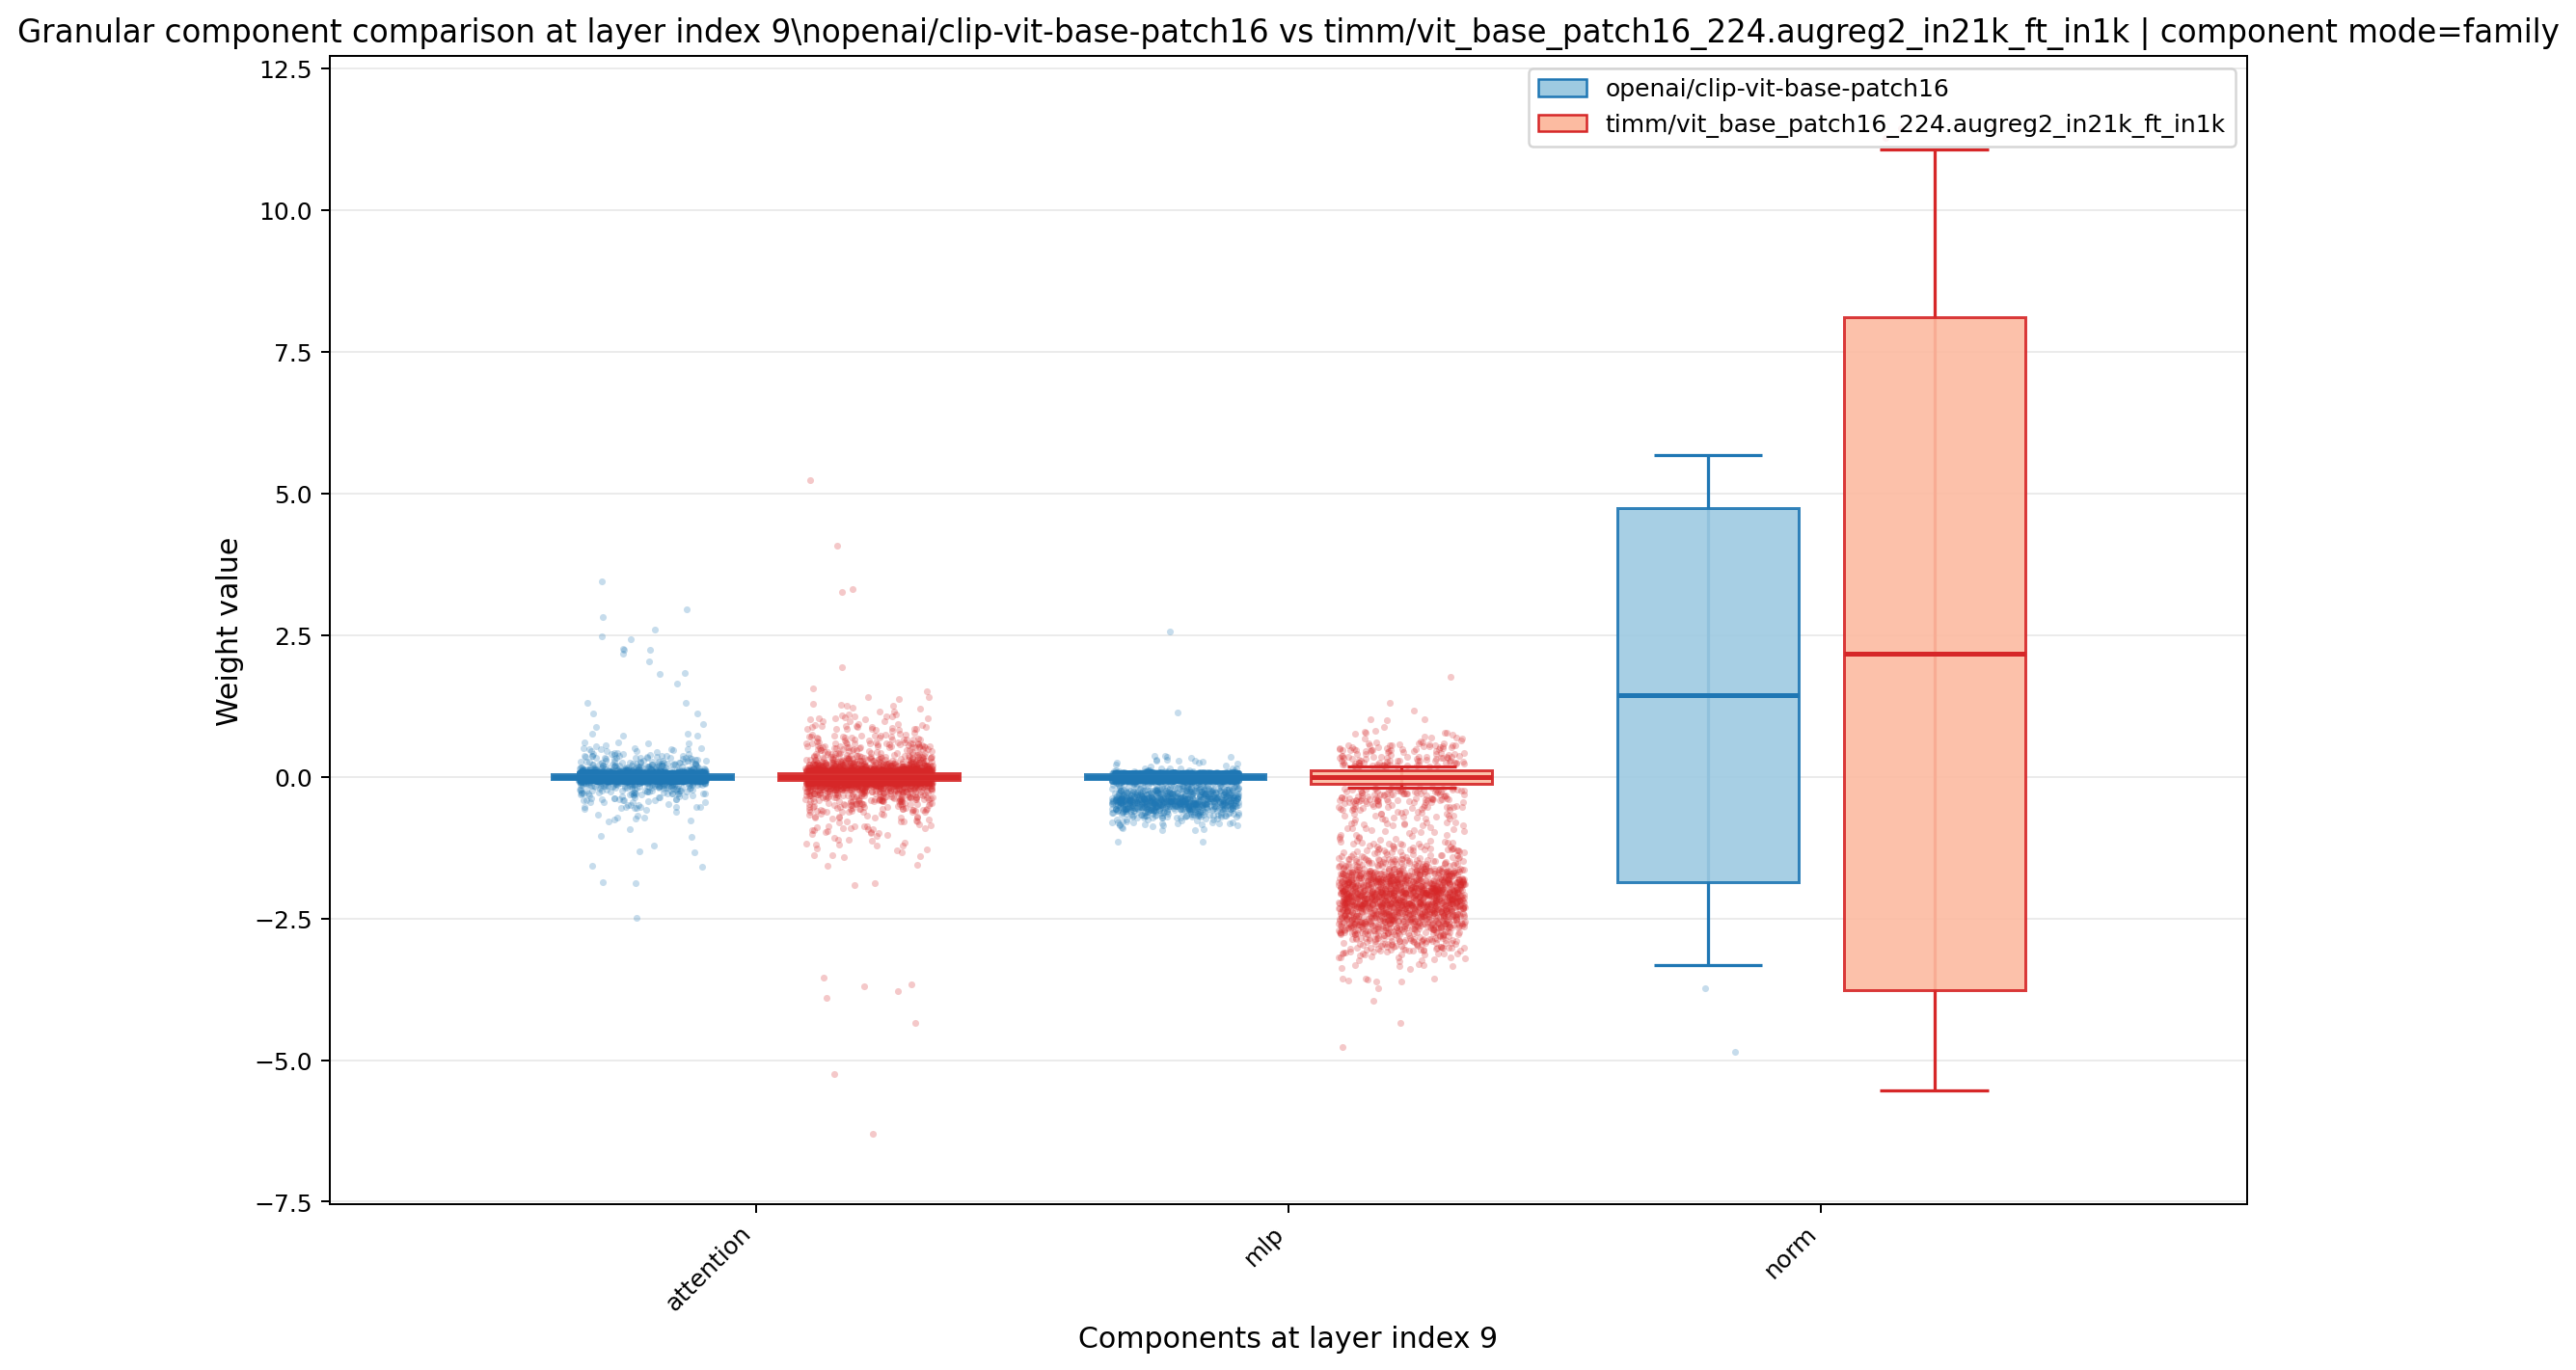

Plotting granular view for layer index 10 with 3 common components


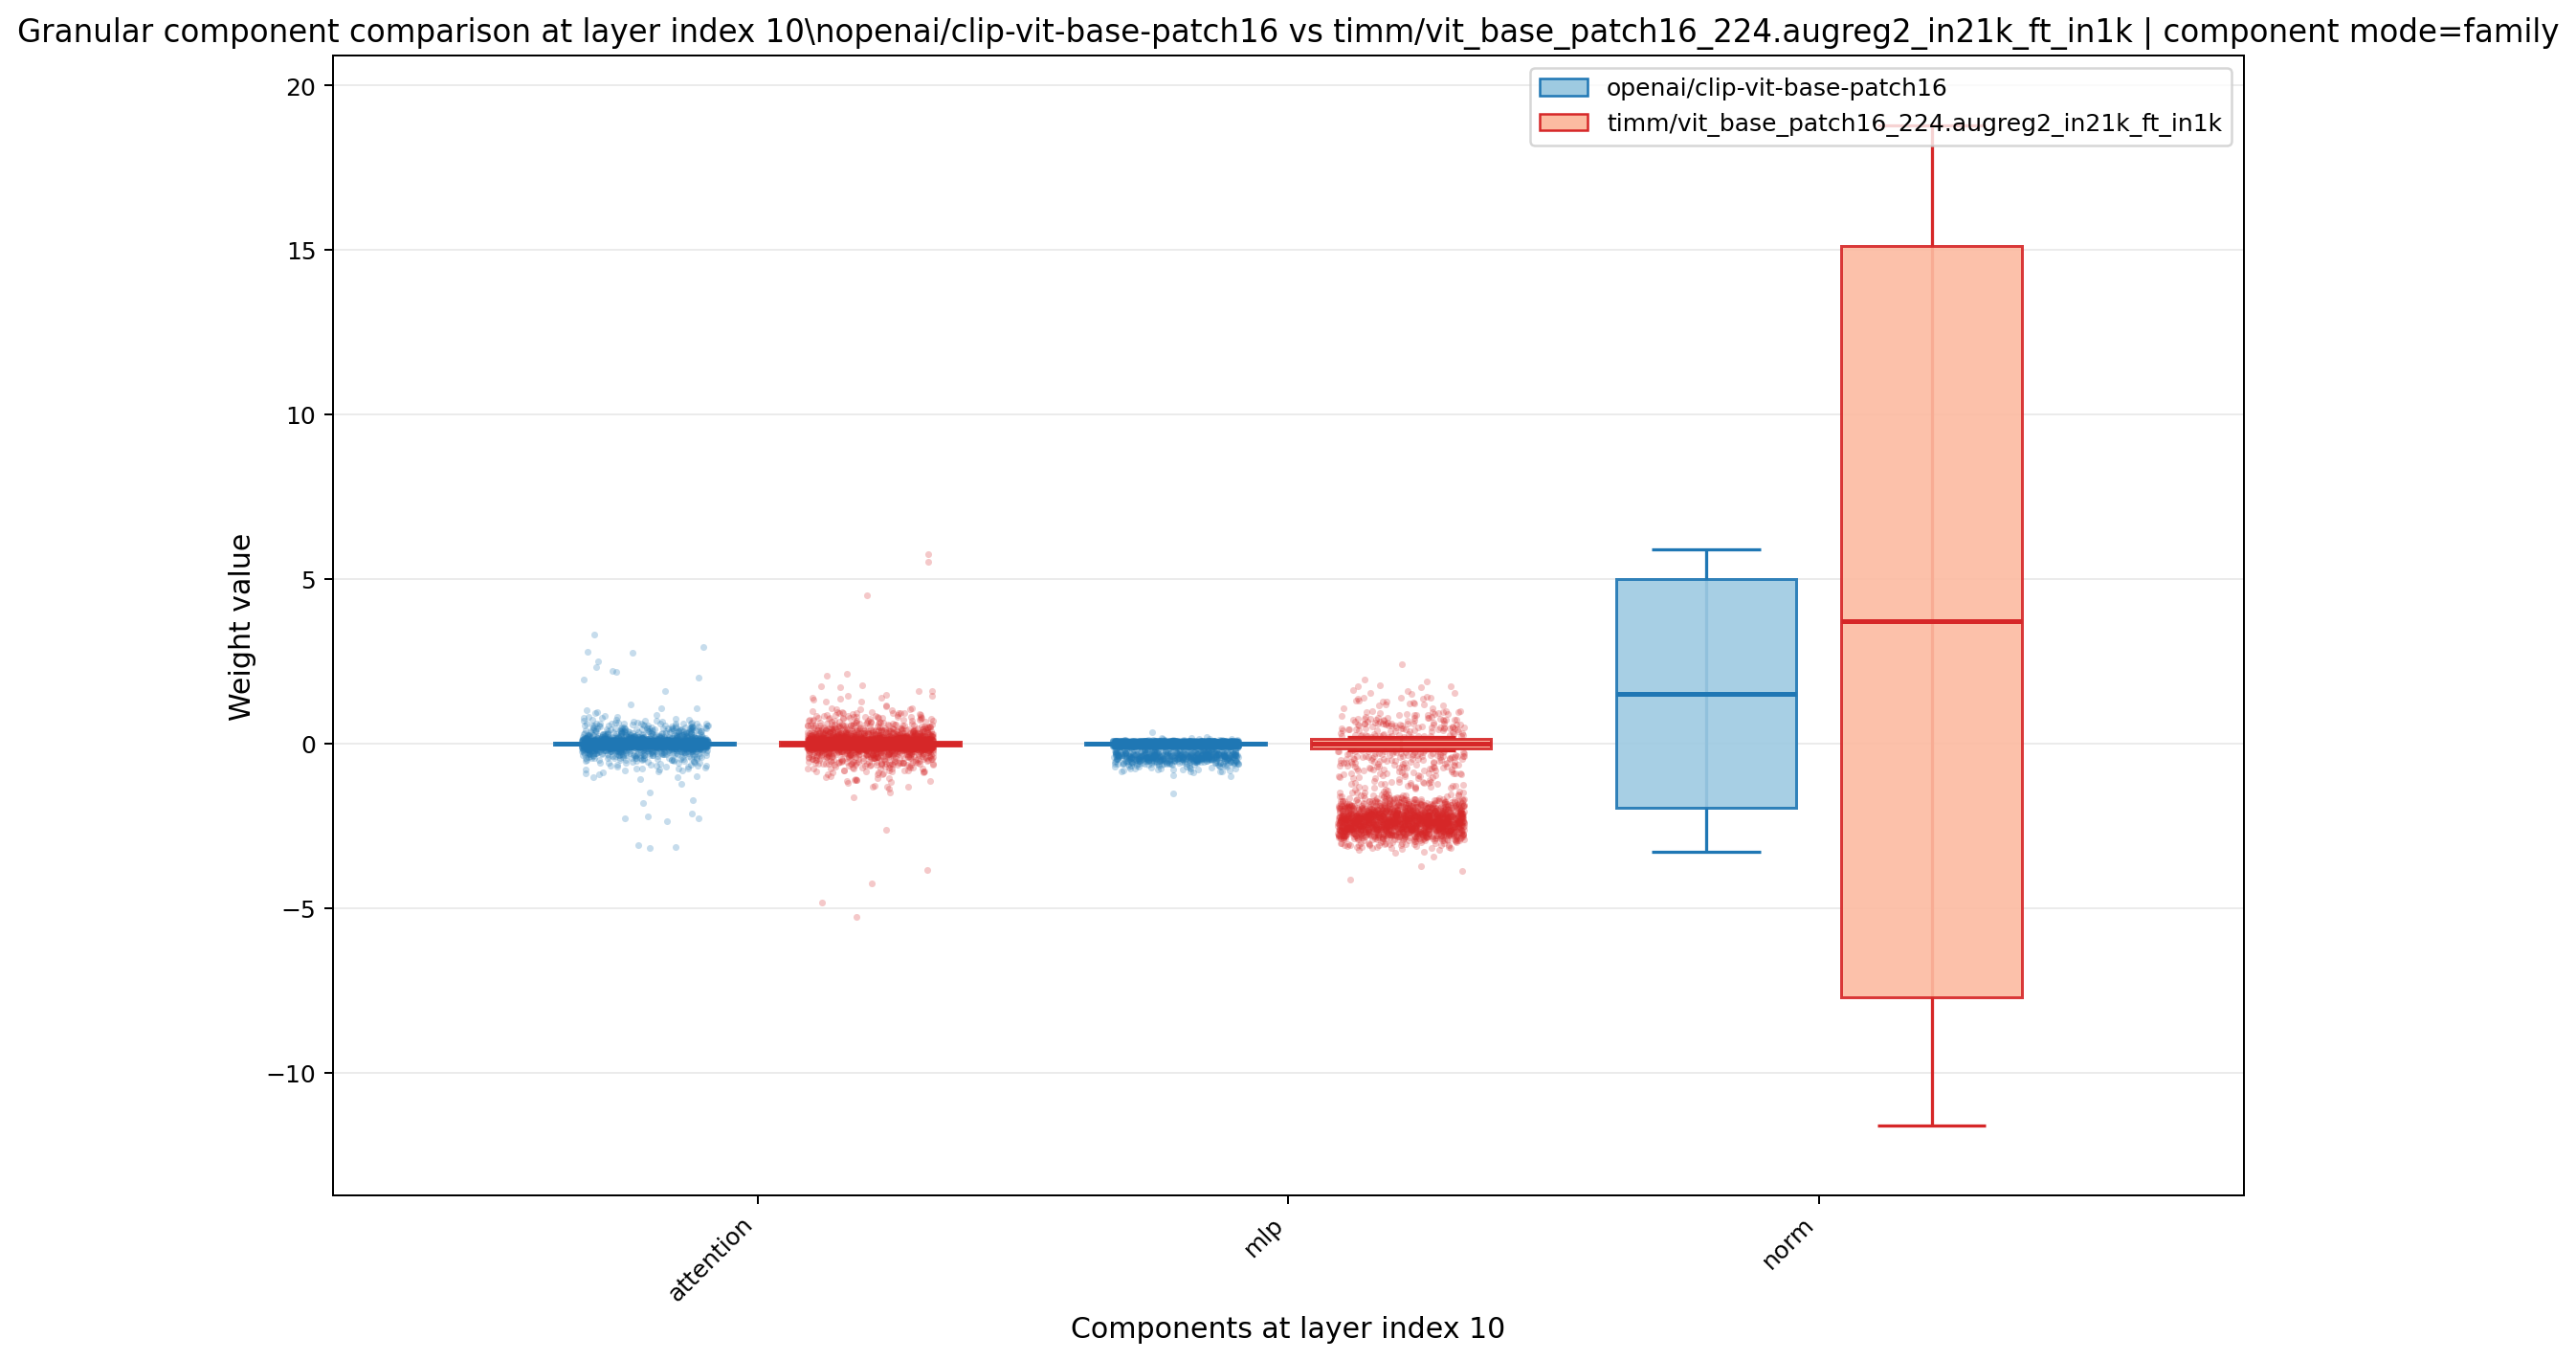

Plotting granular view for layer index 11 with 3 common components


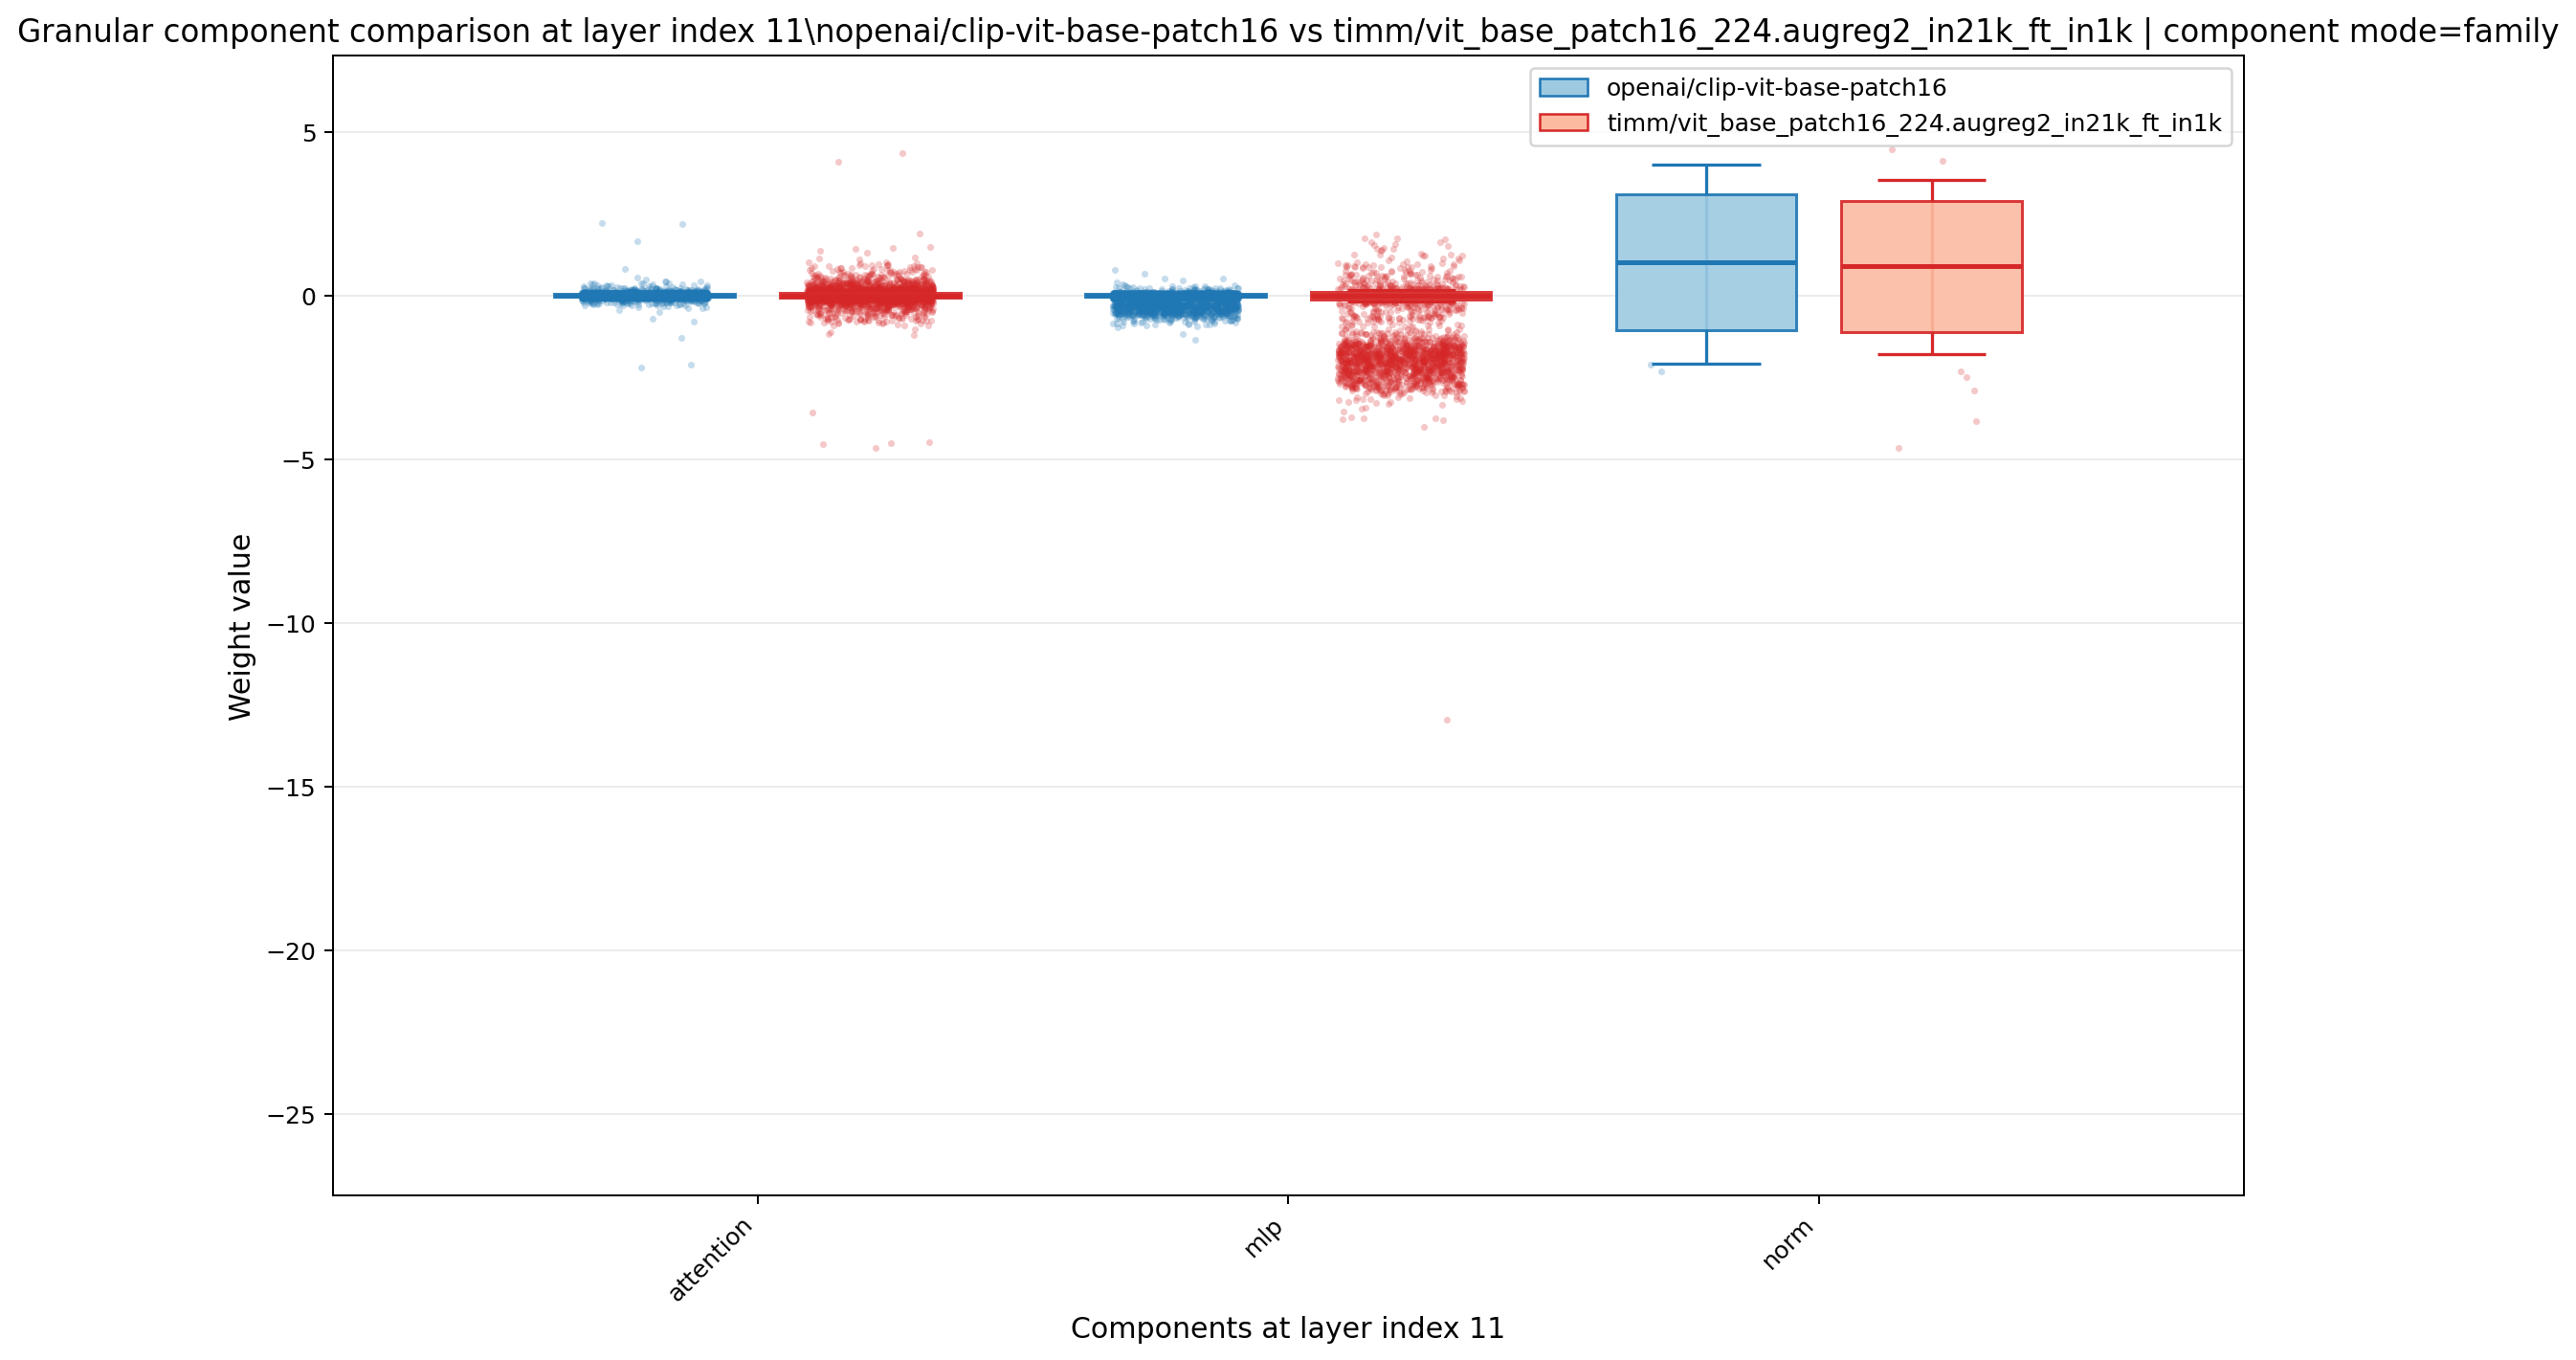

In [8]:
component_layer_indices = sorted(set(component_stats_a) & set(component_stats_b))
if not component_layer_indices:
    raise RuntimeError("No common layer indices available for granular component comparison.")

print(f"Granular layer indices available: {component_layer_indices}")

if PLOT_GRANULAR_FOR_ALL_COMMON_LAYERS:
    for layer_idx in component_layer_indices:
        components_here = sorted(
            set(component_stats_a.get(layer_idx, {})) & set(component_stats_b.get(layer_idx, {}))
        )
        if not components_here:
            print(f"Skipping layer index {layer_idx}: no common components")
            continue
        print(
            f"Plotting granular view for layer index {layer_idx} with {len(components_here)} common components"
        )
        plot_component_candlesticks_for_layer(
            component_stats_a=component_stats_a,
            component_stats_b=component_stats_b,
            model_a_name=MODEL_A,
            model_b_name=MODEL_B,
            layer_idx=layer_idx,
        )
else:
    selected_layer_idx = (
        component_layer_indices[0] if LAYER_INDEX_TO_INSPECT is None else LAYER_INDEX_TO_INSPECT
    )
    if selected_layer_idx not in component_layer_indices:
        raise RuntimeError(
            f"Layer index {selected_layer_idx} is not available. Choose one of: {component_layer_indices}"
        )
    plot_component_candlesticks_for_layer(
        component_stats_a=component_stats_a,
        component_stats_b=component_stats_b,
        model_a_name=MODEL_A,
        model_b_name=MODEL_B,
        layer_idx=selected_layer_idx,
    )